#### Описание проекта

Предоставлены данные  некоторых пользователях из нескольких городов, а также данные об их поездках. Проанализиурем их, посдчитаем выурчку и проверим некоторые гипотезы. 

In [1]:
# импортируем все нужные пакеты
import pandas as pd
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt 
import pylab as pl
from scipy import stats as st

#### Шаг 1. Загрузка данных

In [2]:
# загружаем все три датасета 
try:
    original_data_users = pd.read_csv('C:/Users/USER/project_4/users_go.csv')
except:
    original_data_users= pd.read_csv('/datasets/users_go.csv')
    
try:
    original_data_rides = pd.read_csv('C:/Users/USER/project_4/rides_go.csv')
except:
    original_data_rides= pd.read_csv('/datasets/rides_go.csv')
    
try:
    original_data_subscriptions = pd.read_csv('C:/Users/USER/project_4/subscriptions_go.csv')
except:
    original_data_subscriptions= pd.read_csv('/datasets/subscriptions_go.csv')
    


Описание данных о пользователях:
* "ser_id"  &ndash; уникальный идентификатор пользователя;
* "name"  &ndash;	имя пользователя;
* "age" &ndash; возраст;
* "city" &ndash; город;
* "subscription_type" &ndash; тип подписки (free, ultra);
    

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1565 entries, 0 to 1564
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user_id            1565 non-null   int64 
 1   name               1565 non-null   object
 2   age                1565 non-null   int64 
 3   city               1565 non-null   object
 4   subscription_type  1565 non-null   object
dtypes: int64(2), object(3)
memory usage: 61.3+ KB


,user_id,name,age,city,subscription_type
0,1,Кира,22,Тюмень,ultra
1,2,Станислав,31,Омск,ultra
2,3,Алексей,20,Москва,ultra
3,4,Константин,26,Ростов-на-Дону,ultra
4,5,Адель,28,Омск,ultra
5,6,Регина,25,Краснодар,ultra
6,7,Игорь,23,Омск,ultra
7,8,Юрий,23,Краснодар,ultra
8,9,Ян,21,Пятигорск,ultra
9,10,Валерий,18,Екатеринбург,ultra


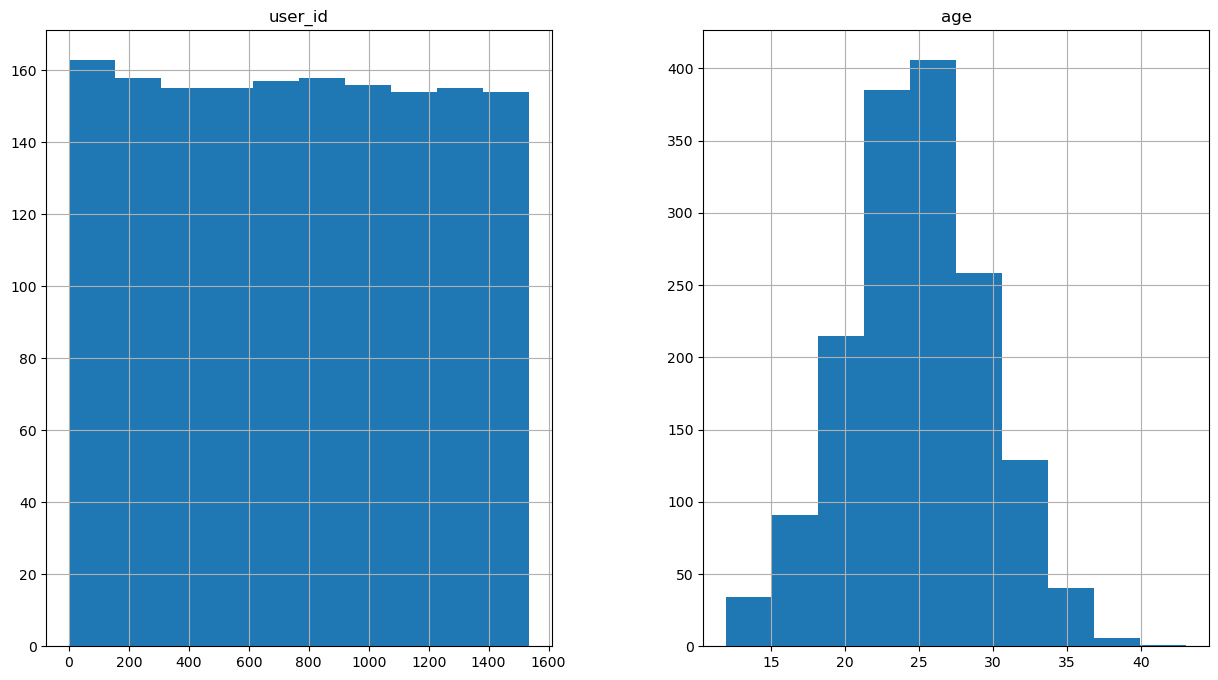

In [3]:
# основная информация о данных по пользователям
original_data_users.info()
display(original_data_users.head(10))
original_data_users.hist(figsize=(15, 8));

На первый взгляд в данных о пользователях нет пропущенных или аномальных значений, но возможны дубликаты.

Описание данных о поездках:
* "subscription_type" &ndash; тип подписки;
* "minute_price" &ndash; стоимость одной минуты поездки по данной подписке;
* "start_ride_price" &ndash; стоимость начала поездки;
* "subscription_fee" &ndash; стоимость ежемесячного платежа;

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18068 entries, 0 to 18067
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   user_id   18068 non-null  int64  
 1   distance  18068 non-null  float64
 2   duration  18068 non-null  float64
 3   date      18068 non-null  object 
dtypes: float64(2), int64(1), object(1)
memory usage: 564.8+ KB


,user_id,distance,duration,date
0,1,4409.919140,25.599769,2021-01-01
1,1,2617.592153,15.816871,2021-01-18
2,1,754.159807,6.232113,2021-04-20
3,1,2694.783254,18.511000,2021-08-11
4,1,4028.687306,26.265803,2021-08-28
5,1,2770.890808,16.650138,2021-10-09
6,1,3039.020292,14.927879,2021-10-19
7,1,2842.118050,23.117468,2021-11-06
8,1,3412.690668,15.238072,2021-11-14
9,1,748.690645,15.041884,2021-11-22


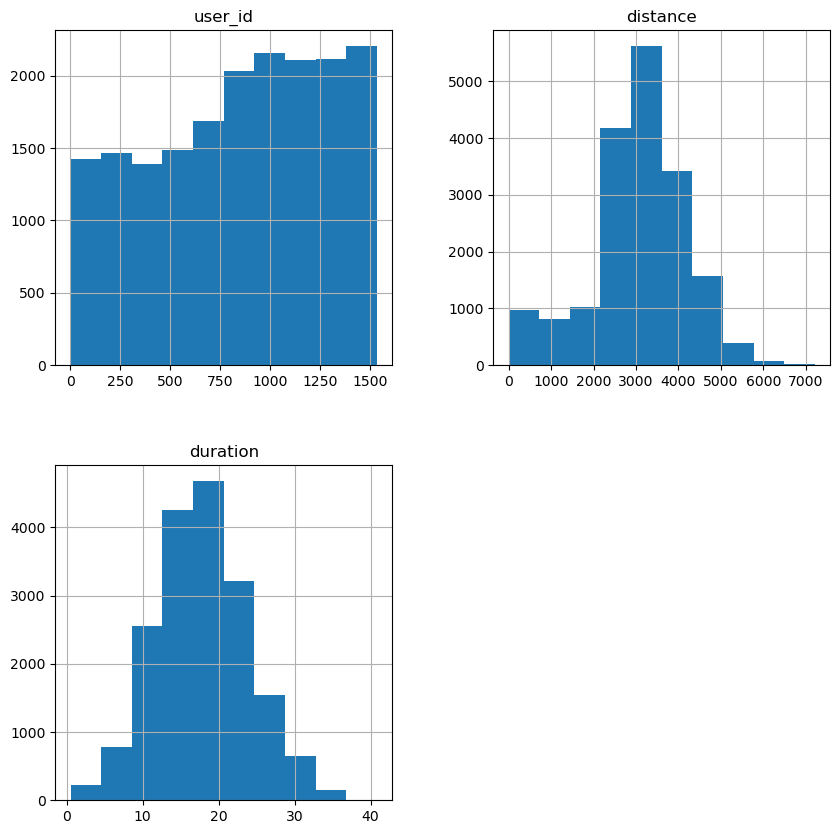

In [4]:
# основная информация о данных по поездкам
original_data_rides.info()
display(original_data_rides.head(10))
original_data_rides.hist(figsize=(10, 10));

В данных о поездках нет пропущенных, и, на первый взгляд, нет аномальных значений.
Значения в колонке "date" надо привести к типу даты pandas.

Также стоит внимательнее посмотреть на продолжительность и расстояние поездок, близких к нулю.

Описание данныx о подписке:
* "subscription_type" &ndash; тип подписки;
* "minute_price" &ndash; стоимость одной минуты поездки по данной подписке;
* "start_ride_price" &ndash; стоимость начала поездки;
* "subscription_fee" &ndash; стоимость ежемесячного платежа;

In [5]:
# основная информация о данных по полдпискам
original_data_subscriptions.info()
display(original_data_subscriptions.head(10))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   subscription_type  2 non-null      object
 1   minute_price       2 non-null      int64 
 2   start_ride_price   2 non-null      int64 
 3   subscription_fee   2 non-null      int64 
dtypes: int64(3), object(1)
memory usage: 196.0+ bytes


,subscription_type,minute_price,start_ride_price,subscription_fee
0,free,8,50,0
1,ultra,6,0,199


Есть бесплатная подписка и платная. Аномалий нет.

#### Шаг 2. Предобработка данных

##### Создание копий датасетов

Прежде, чем обрабатывать, анализировать или изменять данные создатим копии исходных данных и будем работать уже с ними.

In [6]:
data_users=original_data_users.copy()
data_rides=original_data_rides.copy()
data_subscriptions=original_data_subscriptions.copy()

#####  Приведение данных к корректному формату и добавление столбца

Переведем значния в столбце "date" датасета "data_rides" к формату дата.

In [7]:
# приводим к формату дата
data_rides['date'] = pd.to_datetime(data_rides['date'])


Добавим столбец с месяцем поездки.

In [8]:
data_rides['month']= data_rides['date'].dt.month

#проверяем что сработало
data_rides.info()
display(data_rides.head(6))
# смотрим, за какой срок представлены данные
print('Дата последней поездки:',data_rides['date'].max(),'\nДата первой поездки:', data_rides['date'].min())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18068 entries, 0 to 18067
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   user_id   18068 non-null  int64         
 1   distance  18068 non-null  float64       
 2   duration  18068 non-null  float64       
 3   date      18068 non-null  datetime64[ns]
 4   month     18068 non-null  int32         
dtypes: datetime64[ns](1), float64(2), int32(1), int64(1)
memory usage: 635.3 KB


,user_id,distance,duration,date,month
0,1,4409.919140,25.599769,2021-01-01,1
1,1,2617.592153,15.816871,2021-01-18,1
2,1,754.159807,6.232113,2021-04-20,4
3,1,2694.783254,18.511000,2021-08-11,8
4,1,4028.687306,26.265803,2021-08-28,8
5,1,2770.890808,16.650138,2021-10-09,10


Дата последней поездки: 2021-12-30 00:00:00 
Дата первой поездки: 2021-01-01 00:00:00


Представлены данные за 2021 год.

#####  Поиск, анализ и обработка пропущенных значений и дубликатов

Пропущенных значений в датасетах нет (выяснили это ранее, из общей информации о датасетах).

Ищем и удаляем явные дубликаты в датасете "data_users".

In [9]:
data_users.duplicated().sum()
#display(data_users[data_users.duplicated()])
data_users=data_users.drop_duplicates()

In [10]:
# проверяем что все удалили
data_users.duplicated().sum()

0

Теперь проверим датасет "data_users" на неявные дубликаты. В этом дадасете неявные дубликаты могут появиться засчет разногого написания названий городов.

In [11]:
print(data_users['city'].sort_values().unique()) 

['Екатеринбург' 'Краснодар' 'Москва' 'Омск' 'Пятигорск' 'Ростов-на-Дону'
 'Сочи' 'Тюмень']


Неявных дубликатов нет.

Проверим "data_rides" на явные дубликаты.

In [12]:
data_rides.duplicated().sum()

0

В датасете "data_rides" нет дубликатов, и неявынех дубликатов тоже.

В датасете "data_subscriptions" всего две строчки, дубликатов нет.

#### Шаг 3. Исследовательский анализ данных

Опишем и визуализируем общую информацию о пользователях и поездках.

##### Частота встречаемости городов

count          1534
unique            8
top       Пятигорск
freq            219
Name: city, dtype: object

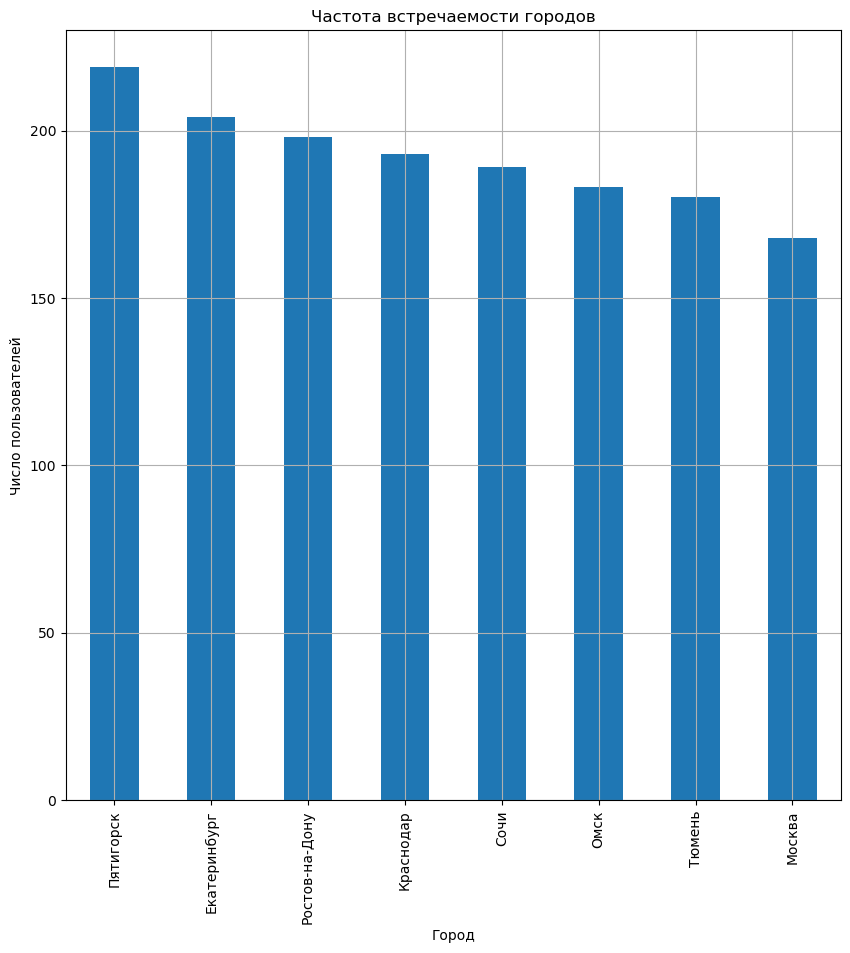

In [13]:

data_users['city'].value_counts().plot(kind='bar',
                                       title="Частота встречаемости городов",grid=True, legend=False, figsize=(10,10));

plt.ylabel("Число пользователей")
plt.xlabel("Город")

data_users['city'].describe()

Всего предоставленны данные о 1584 пользователях из 8 городов.

Для большей наглядности построим диаграмму.

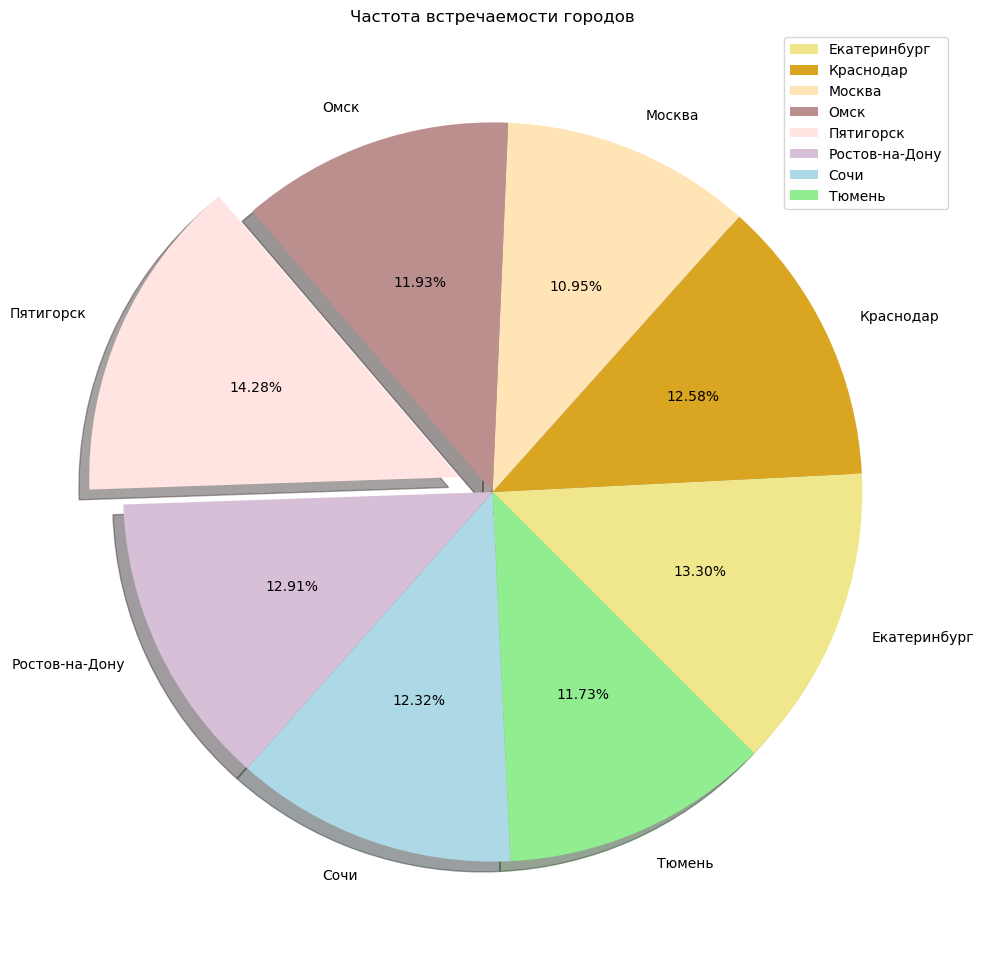

In [14]:
explode = (0, 0, 0, 0,0.1,0,0,0)
diagramm=data_users.groupby('city').size().plot(kind='pie',autopct='%1.2f%%', figsize=(12, 12), legend=True,
                                                explode=explode,shadow=True,startangle=-45,
                                                colors=['khaki', 'goldenrod', 'moccasin',
                                                        'rosybrown','mistyrose','thistle', 'lightblue','lightgreen'],
                                               title="Частота встречаемости городов");
diagramm.set_ylabel(" ");

В целом, распределение пользователей по городам довольно равномерное, хотя в предоставленной выборке пользователей из Пятигорска несколько больше. 

##### Cоотношение пользователей с подпиской и без подписки

In [15]:
data_users['subscription_type'].describe()

count     1534
unique       2
top       free
freq       835
Name: subscription_type, dtype: object

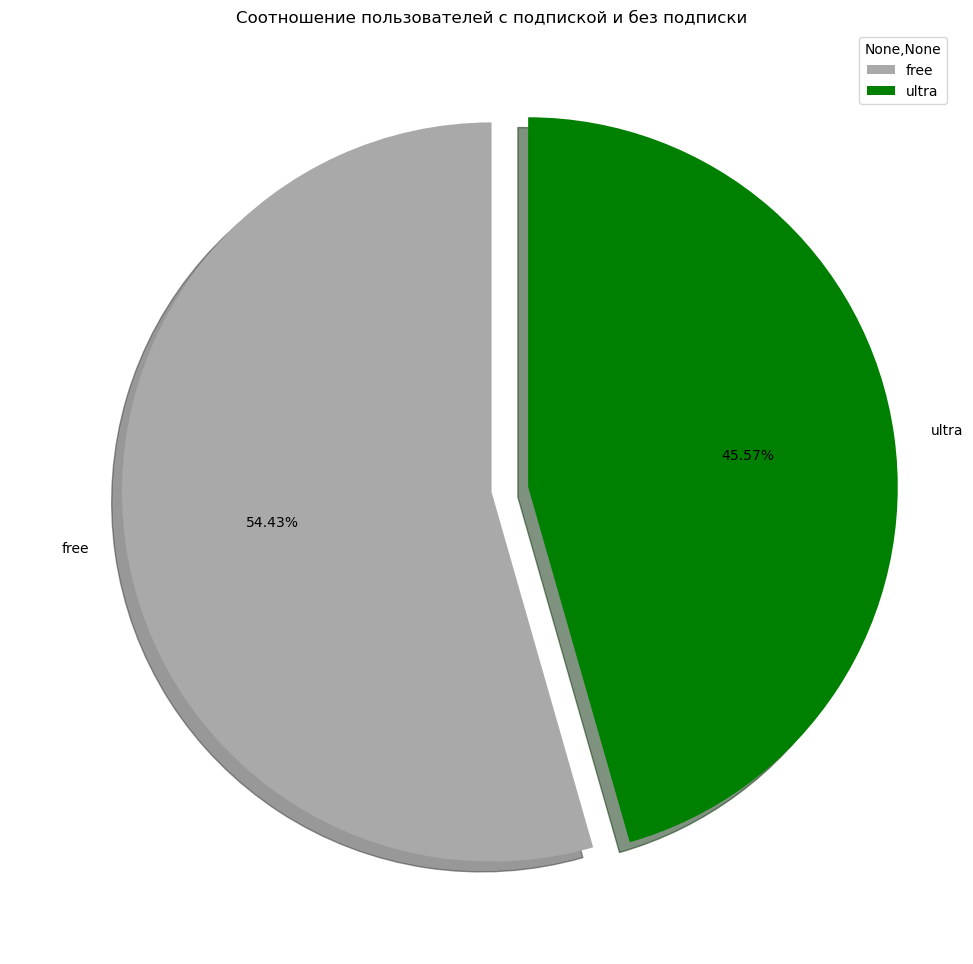

In [16]:
explode2=(0, 0.1)
diagramm2=data_users.pivot_table(index='subscription_type', values='user_id', aggfunc=['count'])

diagramm2=diagramm2.plot(y=('count','user_id'),kind='pie',autopct='%1.2f%%', figsize=(12, 12), legend=True,
                         explode=explode2,shadow=True, startangle=90,
                         colors=['darkgray', 'green'],
                        title="Cоотношение пользователей с подпиской и без подписки");
diagramm2.set_ylabel(" ");

Из 1534 пользователей платную подписку оформили  45.6% пользователей.

##### Возраст пользователей

In [17]:
data_users['age'].describe()

count    1534.000000
mean       24.903520
std         4.572367
min        12.000000
25%        22.000000
50%        25.000000
75%        28.000000
max        43.000000
Name: age, dtype: float64

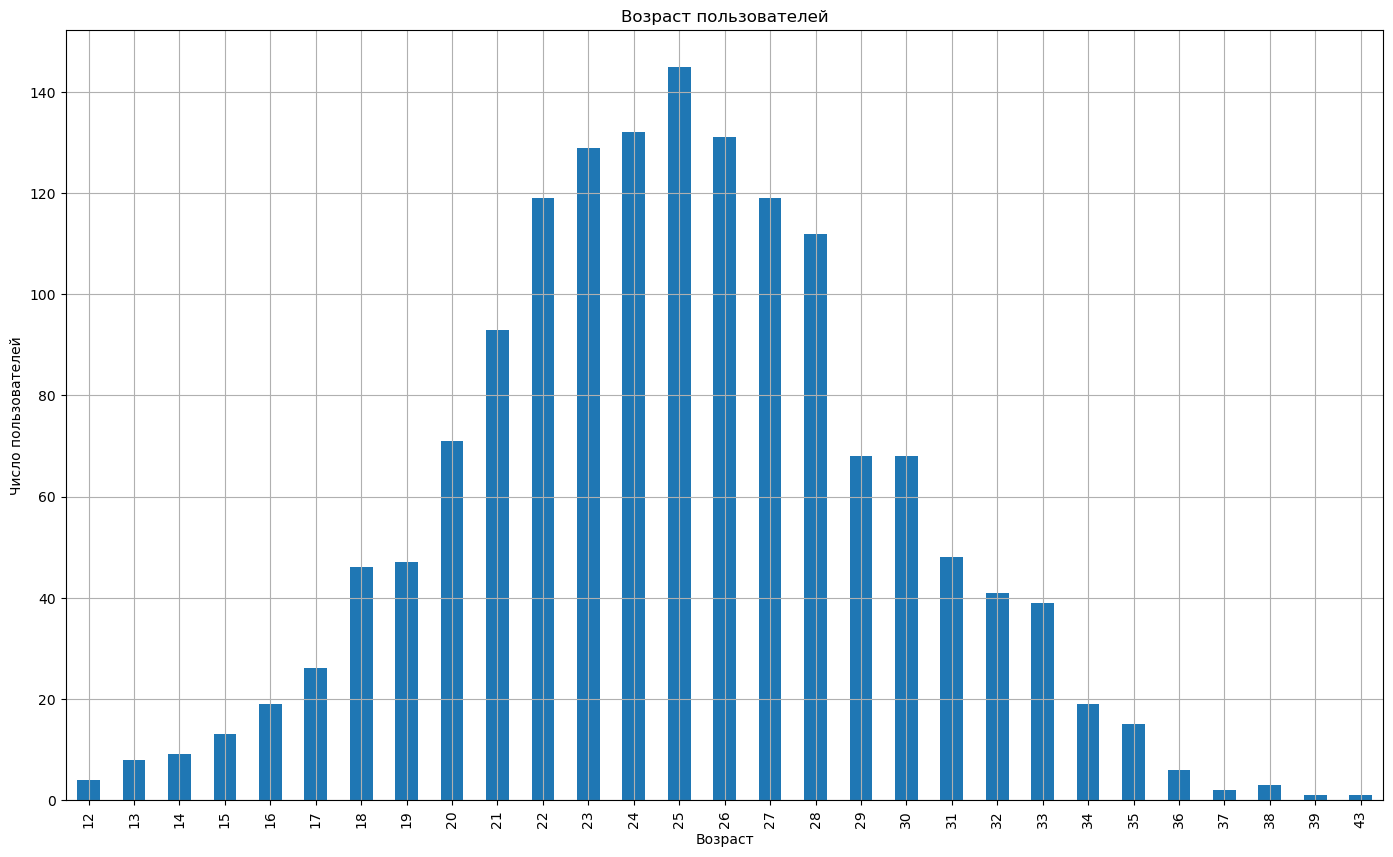

In [18]:
data_users['age'].value_counts().sort_index().plot(kind='bar',grid=True, legend=False,
                                                   title="Возраст пользователей", figsize=(17,10));
plt.xlabel("Возраст")
plt.ylabel("Число пользователей");

In [19]:
print('Коэффициент асимметрии:', data_users['age'].skew())
data_users.query('age<18').shape[0]

Коэффициент асимметрии: 0.04241710507526224


79

Медианный  возраст пользователя &ndash; 25 лет, средний &ndash; 24.9.  

Расспределение почти симметричное.

Также в выборку попали пользователи моложе 18. В предоставленных данных пользователей возраста 12-17 лет чуть больше 5%. В целом, неудивительно, что подростки пользуются сервисом. Вероятно, в 2021 году это не было противозаконно.  



##### Расстояние и продолжительность  поездки

In [20]:
display(data_rides[['duration', 'distance']].describe())

print('Корреляция между расстоянием и продолжительностью поездок:',
      data_rides['distance'].corr(data_rides['duration']))


,duration,distance
count,18068.000000,18068.000000
mean,17.805011,3070.659976
std,6.091051,1116.831209
min,0.500000,0.855683
25%,13.597563,2543.226360
50%,17.678395,3133.609994
75%,21.724800,3776.222735
max,40.823963,7211.007745


Корреляция между расстоянием и продолжительностью поездок: 0.5367776552505348


Cредняя продолжительность поездки 17.8 минут, медианная  &ndash; 17.6.

Средняя дальность поездки &ndash; 3070 м, медианная &ndash; 3133.

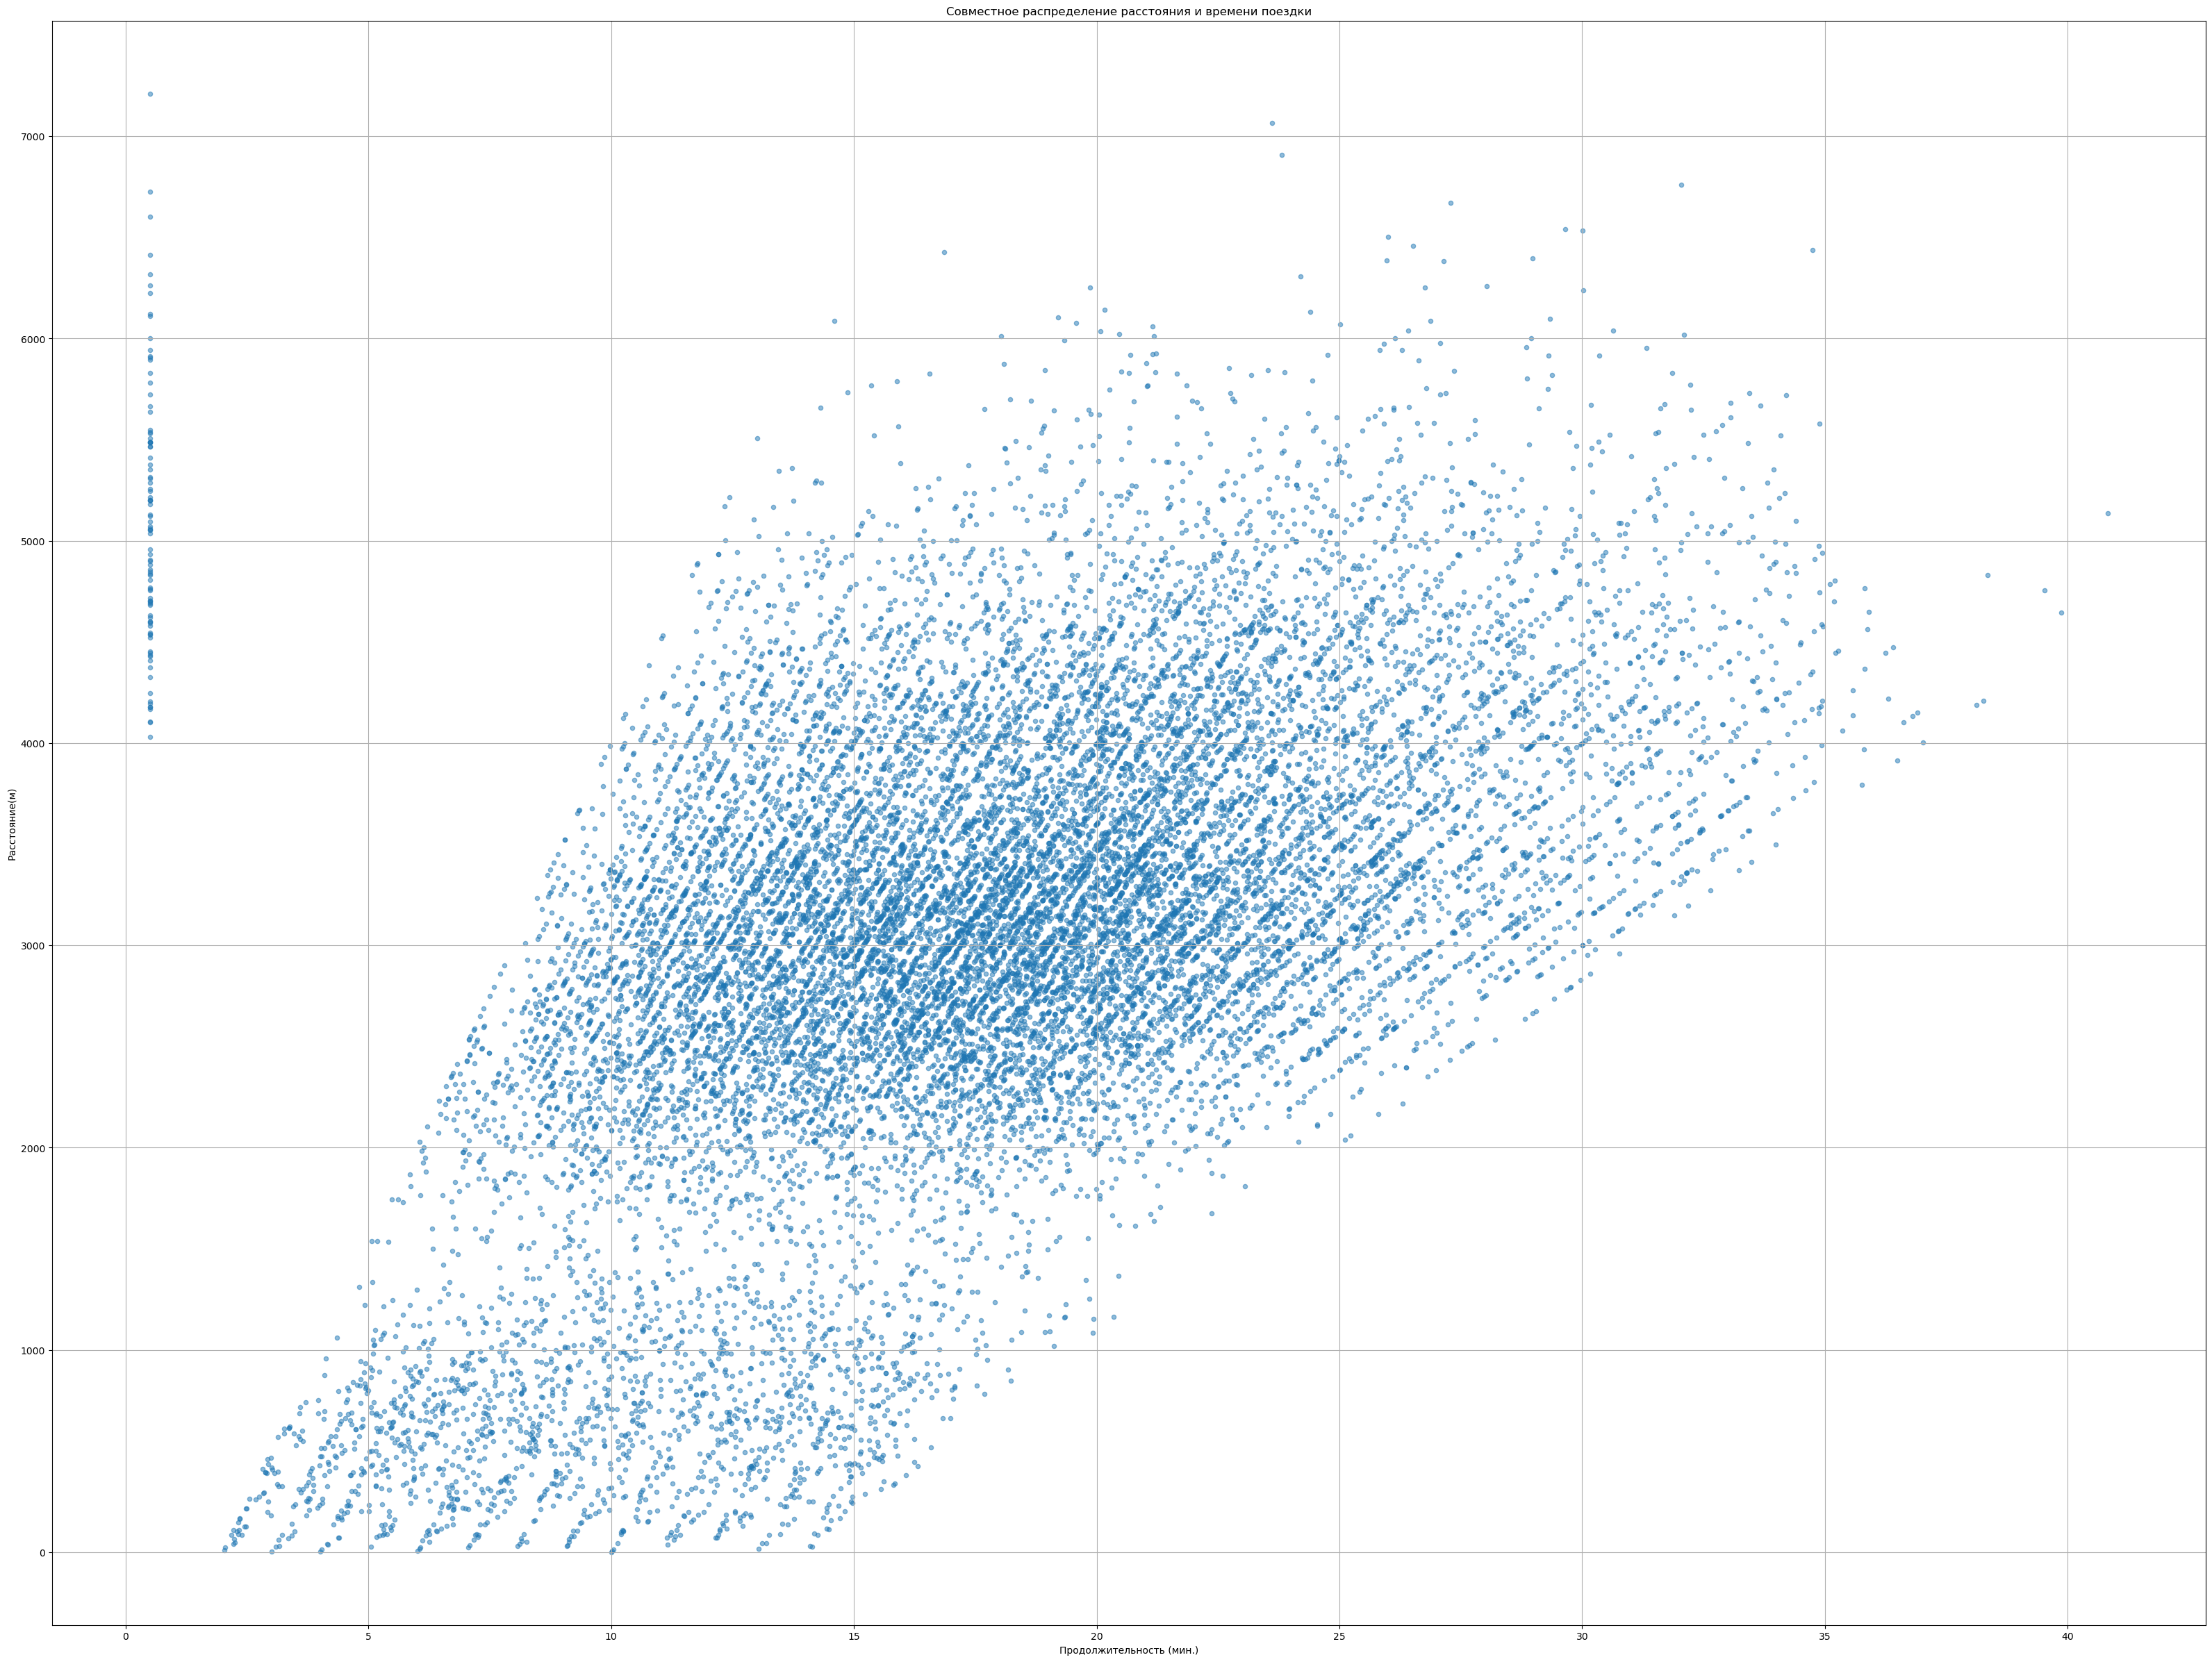

In [21]:
data_rides.plot(x='duration', y = 'distance', kind ='scatter', figsize=(40,30),alpha = 0.5, grid = True,
               title = 'Совместное распределение расстояния и времени поездки');
plt.xlabel('Продолжительность (мин.)');
plt.ylabel('Расстояние(м)');

На графике видны три особенности:
 * (по крайней мере у коротких поездок) есть задержка перед началом движения, при этом её продолжительность кратна одной минуте;
 * поездки группируются по скорости;
 * на линии 0.5 минуты много точек с большими расстояниями, это, очевидно, ошибка учёта времени;
 
Также кажется что между первыми двумя явлениями есть взаимосвязь - чем быстрее запрягают тем быстрее и едут.

К сожалению, по отдельной записи понять к какому кластеру она относится невозможно. Может быть это будет возможно сделать по пользователям, но только тем, у которых достаточно много поездок...

Чтобы разобраться с аномальными значенями, построим гистограмму продолжительности поездки.

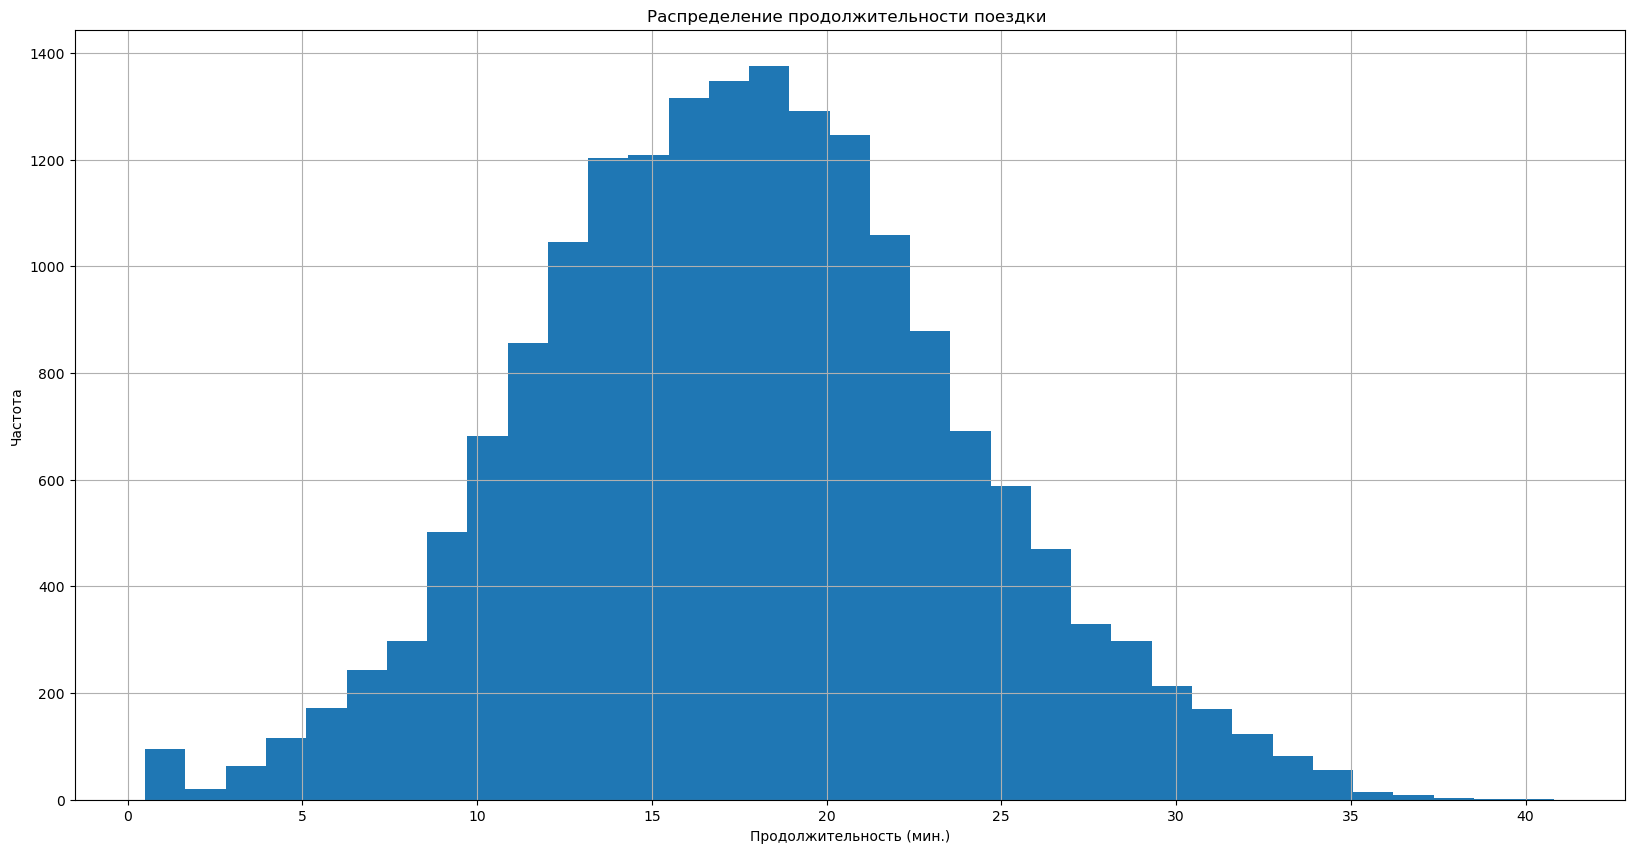

In [22]:
data_rides.plot(kind='hist', y='duration', bins=(35), figsize=(20,10), grid=True,legend=False,
                title='Распределение продолжительности поездки ');

plt.xlabel('Продолжительность (мин.)');
plt.ylabel('Частота');

По гистограмме видно, что есть выброс в райне нуля минут. Посмотрим на данные.

In [23]:
display(data_rides.query('duration<1').sort_values(by='distance',ascending= False).head(15))
#кажется что они все одинаковые, проверим
print(data_rides.query('duration<1')['duration'].min(),'-',data_rides.query('duration<1')['duration'].max())

# 30 минут по ошибке могли занести как 0.5 а не 30
a=data_rides.query('duration==0.5')['distance'].median()
c=len(data_rides.query('duration==0.5'))/data_rides.shape[0]

print(f'Процент аномалий от общего количества записей:{c:.2%}')
print(f'Медианное расстояние аномально быстрых поездок:{a}')

# посмотрим на расстояние, которое проезжают  за 30 минут и дольше
display(data_rides.query('30<=duration').sort_values(by='distance',ascending= False).head(15) )
med2=data_rides.query('30<=duration')['distance'].median()
print(f'Медианное расстояние поездок, дольше 30 минут:{med2}')
#display(data_rides.query('duration==1').sort_values(by='distance',ascending= False))

,user_id,distance,duration,date,month
16309,1411,7211.007745,0.5,2021-04-15,4
17242,1477,6724.932981,0.5,2021-01-12,1
11385,1057,6601.197575,0.5,2021-02-07,2
13701,1224,6414.516026,0.5,2021-07-15,7
14574,1285,6316.574814,0.5,2021-09-25,9
7830,795,6262.302747,0.5,2021-09-09,9
6860,724,6225.520342,0.5,2021-12-16,12
14178,1257,6120.067697,0.5,2021-03-16,3
7612,780,6112.644835,0.5,2021-11-23,11
9622,931,6002.236438,0.5,2021-11-10,11


0.5 - 0.5
Процент аномалий от общего количества записей:0.53%
Медианное расстояние аномально быстрых поездок:5052.769410992954


,user_id,distance,duration,date,month
17171,1471,6760.940067,32.043760,2021-08-03,8
10915,1022,6535.386520,30.008799,2021-10-14,10
8527,850,6436.625605,34.746502,2021-12-27,12
10563,997,6239.565160,30.016996,2021-05-16,5
9451,919,6038.200422,30.643252,2021-05-04,5
13548,1213,6020.364413,32.101822,2021-11-20,11
9415,916,5953.916245,31.327186,2021-12-04,12
16437,1419,5914.977605,30.349904,2021-09-09,9
8519,850,5828.539672,31.857024,2021-04-23,4
9864,949,5773.110632,32.230876,2021-01-05,1


Медианное расстояние поездок, дольше 30 минут:4174.230091239198


Можно было предположить, что продолжительность поездки 0.5 минут это ошибка записи и поразумевалось 30 (0.5 часа) минут и более. Однако медианные значения дистанции аномально быстрых поездок и долгих поездок довольно сильно отличаются.

Всего же аномальных записий 0.5% от всех, поэтому их можно удалить для данного исследования (при этом у нас изменяться результаты рассчета выручки, но и их оставление тоже сделает этот рассчет некорректным, а также будет добавлять ненужный шум в других исследованиях).

In [24]:
# сразу удалим аномальные данные с продолжительностью 0.5 минуты
to_dell = data_rides.query('duration==0.5').index
data_rides = data_rides.drop(to_dell)
data_rides[data_rides['duration']<=1]

,user_id,distance,duration,date,month


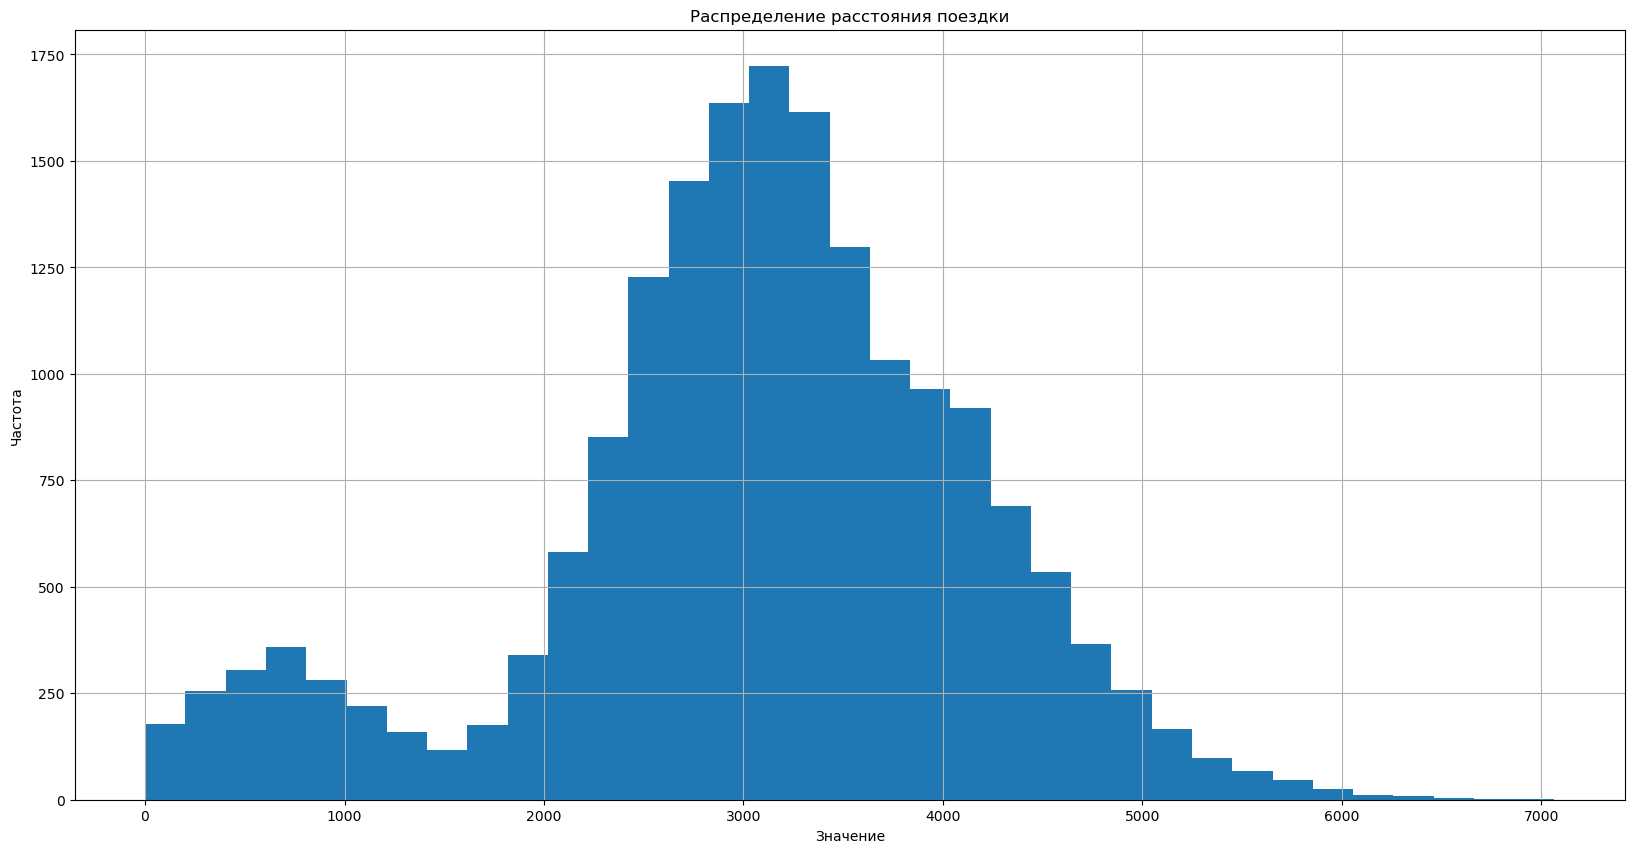

In [25]:
data_rides.plot(kind='hist', y='distance', bins=(35), figsize=(20,10),grid=True, legend=False,
                title="Распределение расстояния поездки");
plt.xlabel('Значение');
plt.ylabel('Частота');


На гистограмме явно выделяются две зоны, посмотрим на каждую из них.

Сначала на короткие.


,user_id,distance,duration,date,month
count,1796.000000,1796.000000,1796.000000,1796,1796.000000
mean,926.052895,703.889720,10.170259,2021-07-02 09:06:00.801781760,6.540646
min,1.000000,0.855683,2.035632,2021-01-01 00:00:00,1.000000
25%,674.500000,414.315810,6.921965,2021-03-27 00:00:00,3.000000
50%,982.000000,687.536713,10.094883,2021-07-04 00:00:00,7.000000
75%,1258.000000,985.430276,13.456112,2021-10-05 06:00:00,10.000000
max,1534.000000,1499.565830,20.457599,2021-12-30 00:00:00,12.000000
std,413.258205,368.353542,3.956201,NaN,3.507098


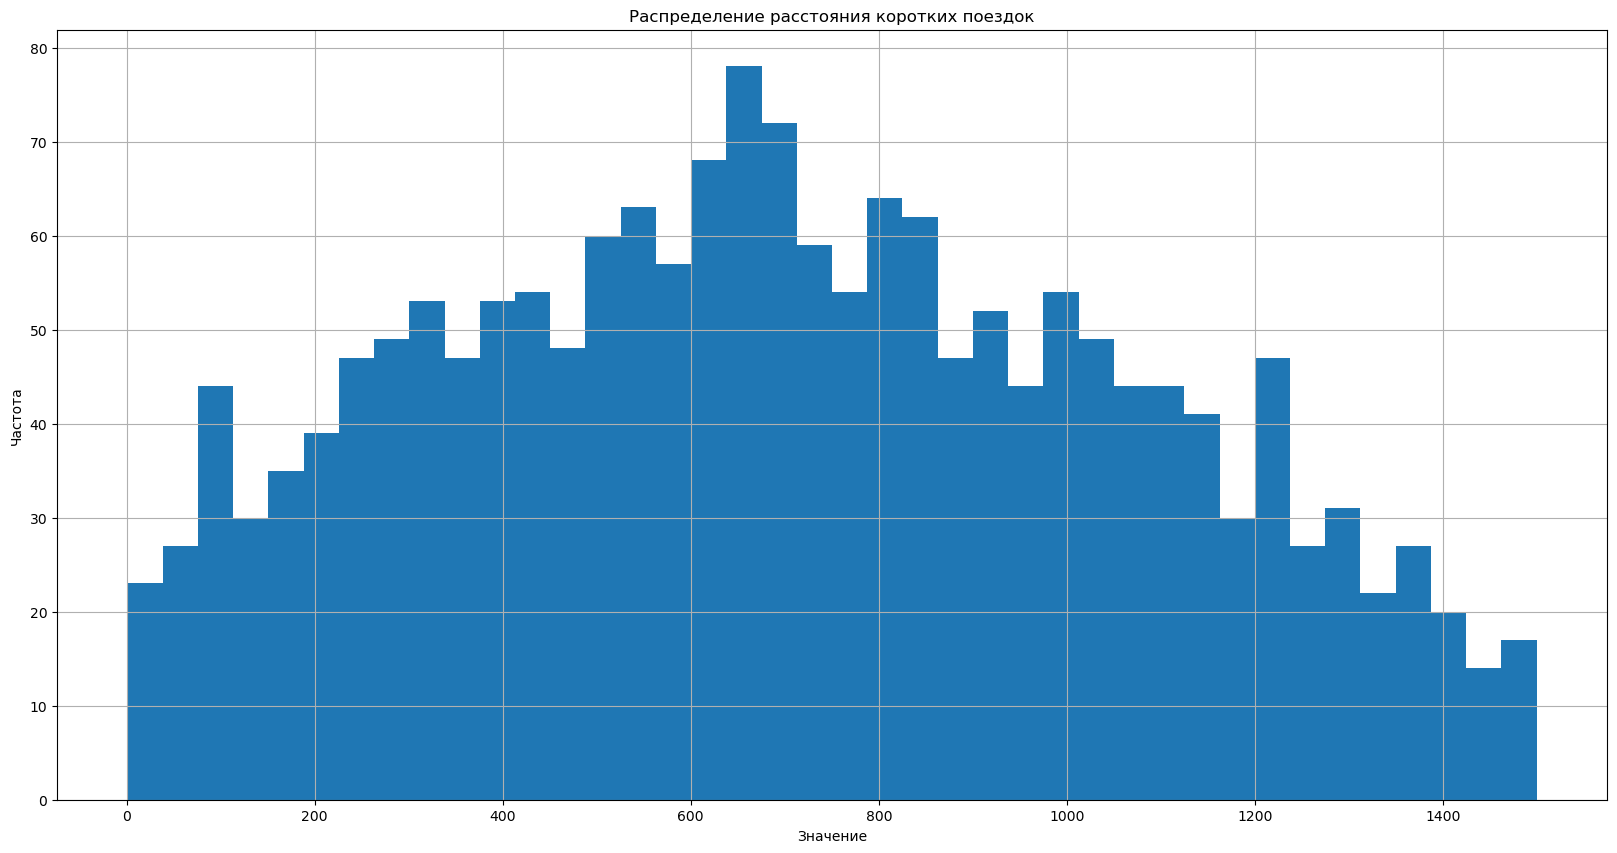

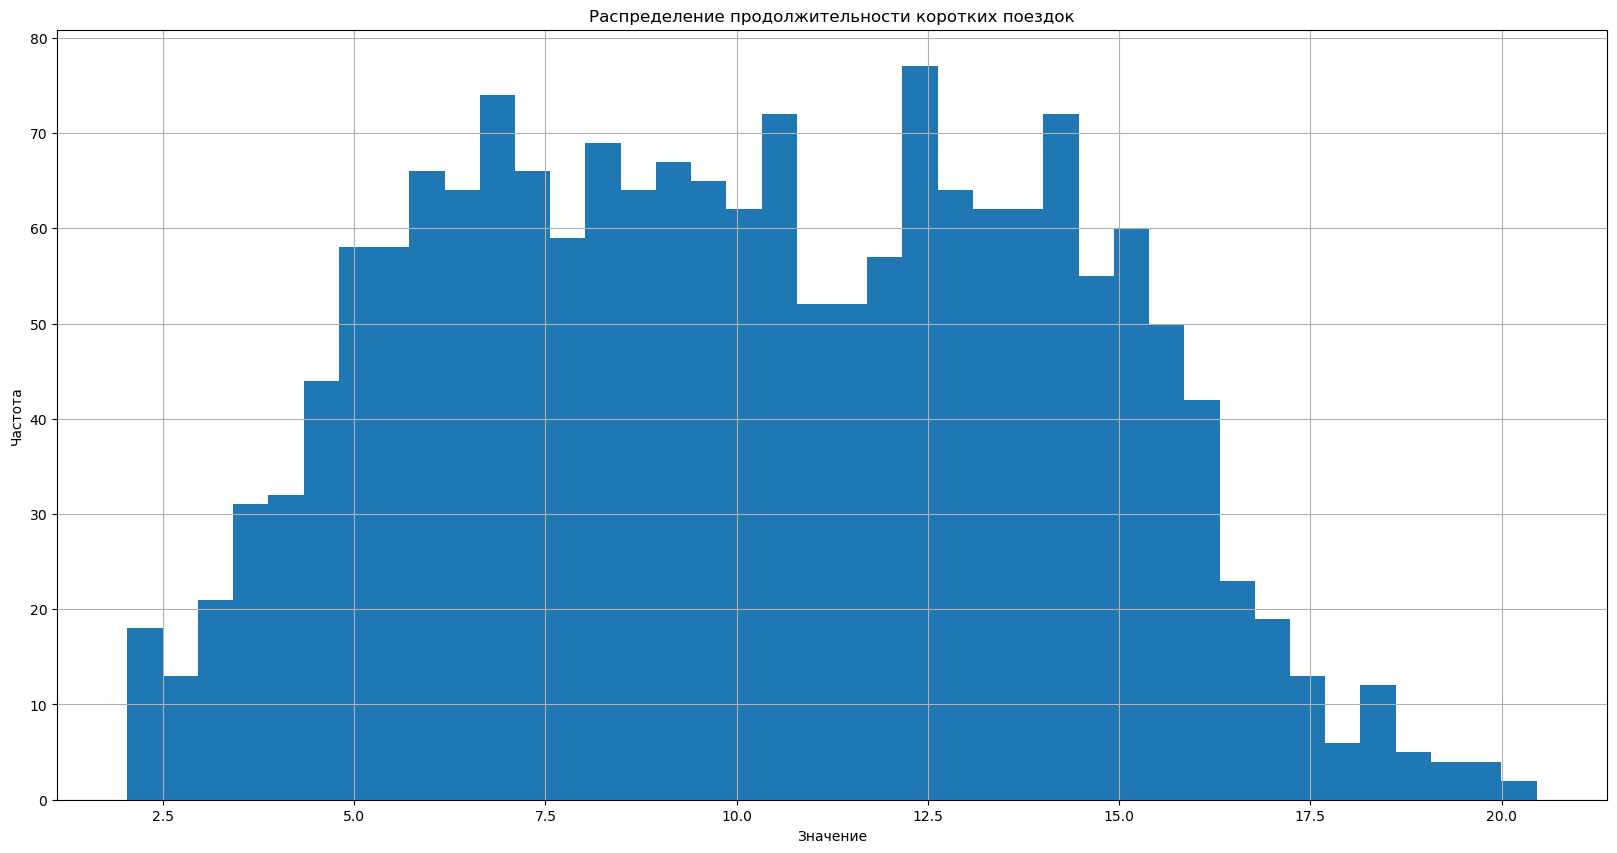

In [26]:

short_rides=data_rides.query('distance<1500')

short_rides.plot(kind='hist', y='distance',bins=(40), figsize=(20,10),grid=True, legend=False,
                                       title="Распределение расстояния коротких поездок");
plt.xlabel('Значение');
plt.ylabel('Частота');
display(short_rides.describe())

short_rides.plot(kind='hist', y='duration',bins=(40), figsize=(20,10),grid=True, legend=False,
                title="Распределение продолжительности коротких поездок");

plt.xlabel('Значение');
plt.ylabel('Частота');


Теперь посмотрим на длинные поездки.

,user_id,distance,duration,date,month
count,16177.000000,16177.000000,16177.000000,16177,16177.000000
mean,832.170551,3321.428369,18.754260,2021-06-30 15:32:26.096309504,6.480806
min,1.000000,1502.431070,5.074442,2021-01-01 00:00:00,1.000000
25%,468.000000,2740.409641,14.673972,2021-04-02 00:00:00,4.000000
50%,876.000000,3233.459921,18.420847,2021-06-29 00:00:00,6.000000
75%,1206.000000,3860.451873,22.246229,2021-09-28 00:00:00,9.000000
max,1534.000000,7066.003772,40.823963,2021-12-30 00:00:00,12.000000
std,436.511771,816.224349,5.528980,NaN,3.428100


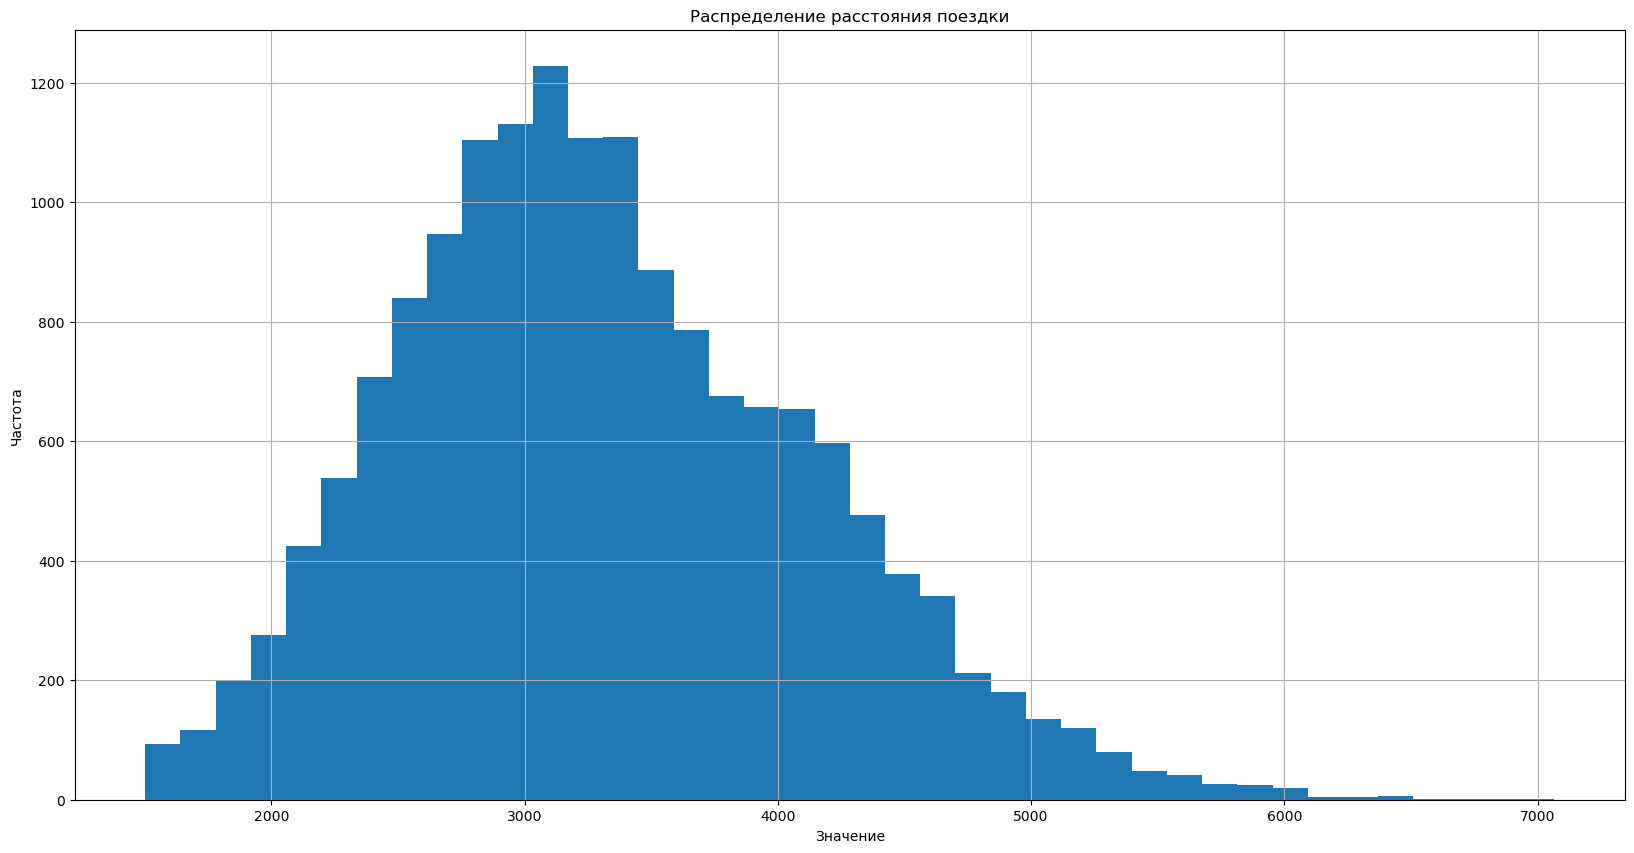

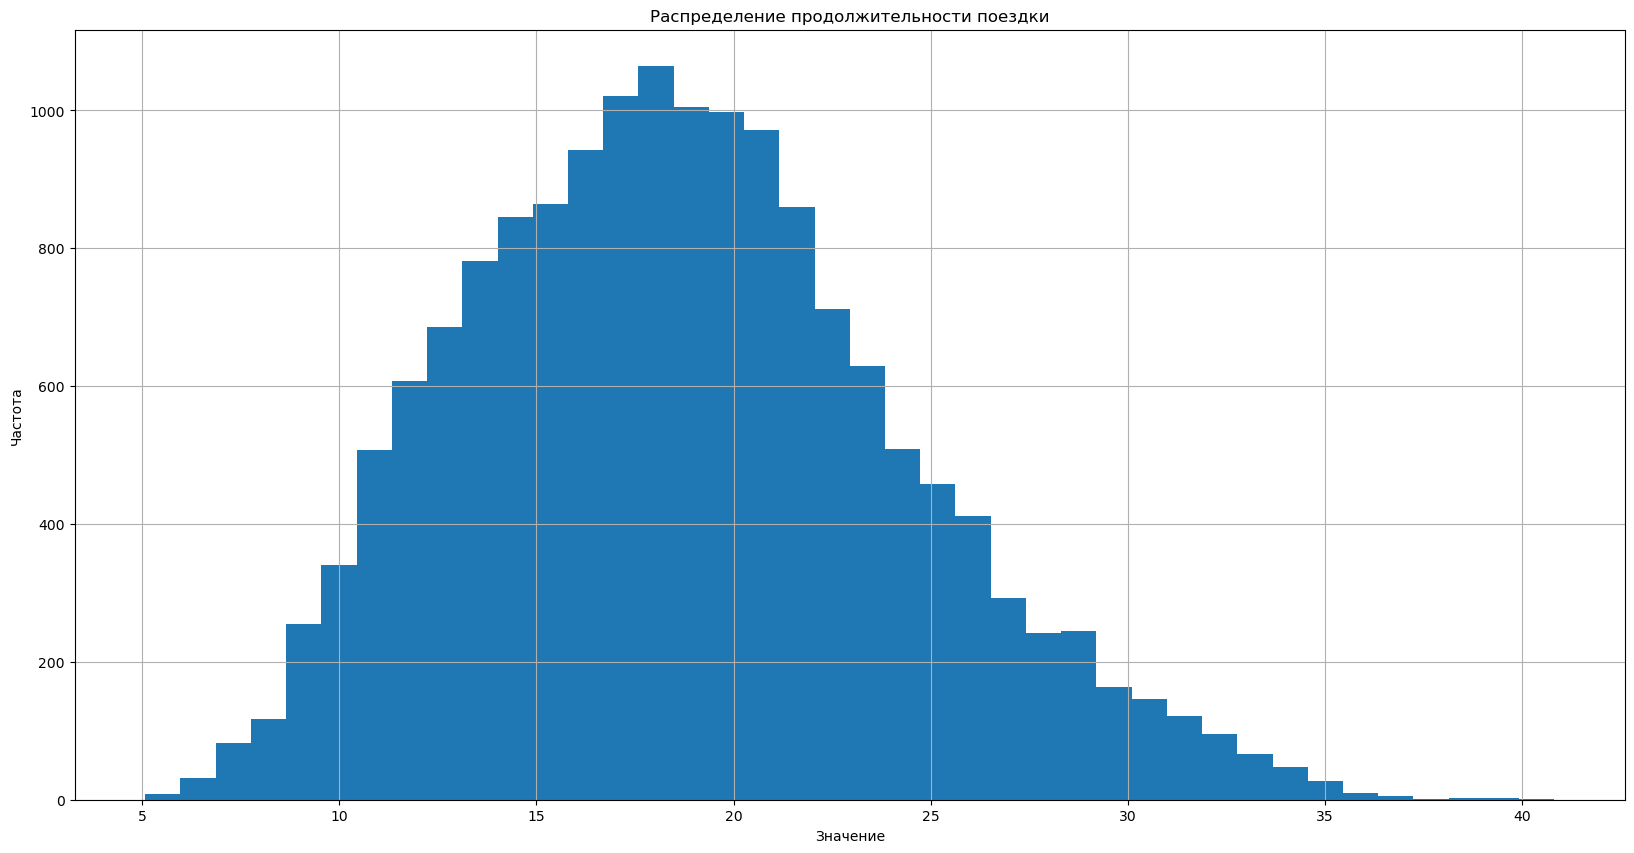

In [27]:
long_rides=data_rides.query('distance>=1500')
long_rides.plot(kind='hist', y='distance',bins=(40), figsize=(20,10),grid=True, legend=False,
                title="Распределение расстояния поездки");

plt.xlabel('Значение');
plt.ylabel('Частота');
display(long_rides.describe())

long_rides.plot(kind='hist', y='duration',bins=(40), figsize=(20,10),grid=True, legend=False,
                title="Распределение продолжительности поездки");
plt.xlabel('Значение');
plt.ylabel('Частота');

В обеих категориях распределения времени и расстояния унимодальные и имеют сходную форму. При этом, так как коротких поездок в 10 раз меньше, гистограммы для них получились более шумные.

In [28]:
display(data_rides[['duration','distance']].describe())

,duration,distance
count,17973.000000,17973.000000
mean,17.896480,3059.863833
std,5.975424,1108.814612
min,2.035632,0.855683
25%,13.670439,2538.839628
50%,17.714122,3129.029255
75%,21.747016,3762.636244
max,40.823963,7066.003772


Средняя дальность поездки &ndash; 3059 м, медианная &ndash; 3129.

Cредняя продолжительность поездки 17.9 минут, медианная  &ndash; 17.7.

После удаление аномалий, средняя и медианная дальность поездок несколько уменьшилась, а продолжительность увеличилась.

#### Шаг 4. Объединение данных

Обединим данные из датафреймов.

In [29]:
data_merge=data_users.merge(data_rides, on='user_id', how='left')
data_merge=data_merge.merge(data_subscriptions, on='subscription_type', how='left')
display(data_merge.head(15))

,user_id,name,age,city,subscription_type,distance,duration,date,month,minute_price,start_ride_price,subscription_fee
0,1,Кира,22,Тюмень,ultra,4409.919140,25.599769,2021-01-01,1,6,0,199
1,1,Кира,22,Тюмень,ultra,2617.592153,15.816871,2021-01-18,1,6,0,199
2,1,Кира,22,Тюмень,ultra,754.159807,6.232113,2021-04-20,4,6,0,199
3,1,Кира,22,Тюмень,ultra,2694.783254,18.511000,2021-08-11,8,6,0,199
4,1,Кира,22,Тюмень,ultra,4028.687306,26.265803,2021-08-28,8,6,0,199
5,1,Кира,22,Тюмень,ultra,2770.890808,16.650138,2021-10-09,10,6,0,199
6,1,Кира,22,Тюмень,ultra,3039.020292,14.927879,2021-10-19,10,6,0,199
7,1,Кира,22,Тюмень,ultra,2842.118050,23.117468,2021-11-06,11,6,0,199
8,1,Кира,22,Тюмень,ultra,3412.690668,15.238072,2021-11-14,11,6,0,199
9,1,Кира,22,Тюмень,ultra,748.690645,15.041884,2021-11-22,11,6,0,199


In [30]:
# проверка таблицы на корректность
data_merge.info()

#проверка на наличие дубликатов
data_merge.duplicated().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17973 entries, 0 to 17972
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            17973 non-null  int64         
 1   name               17973 non-null  object        
 2   age                17973 non-null  int64         
 3   city               17973 non-null  object        
 4   subscription_type  17973 non-null  object        
 5   distance           17973 non-null  float64       
 6   duration           17973 non-null  float64       
 7   date               17973 non-null  datetime64[ns]
 8   month              17973 non-null  int32         
 9   minute_price       17973 non-null  int64         
 10  start_ride_price   17973 non-null  int64         
 11  subscription_fee   17973 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int32(1), int64(5), object(3)
memory usage: 1.6+ MB


0

Размер объединенной таблицы соответсвует ожиданиям, пропуски и дубликаты отсутствуют. Значит, объединение датасетов произошло корректно и как задумывалось.

Создали еще два датасета, разделив пользователей по типу подписки.

In [31]:
data_subscription_free=data_merge[data_merge['subscription_type']=='free'].copy()
display(data_subscription_free.head(10))

data_subscription_ultra=data_merge[data_merge['subscription_type']=='ultra'].copy()
display(data_subscription_ultra.head(10))

,user_id,name,age,city,subscription_type,distance,duration,date,month,minute_price,start_ride_price,subscription_fee
6500,700,Айдар,22,Омск,free,2515.690719,14.944286,2021-01-02,1,8,50,0
6501,700,Айдар,22,Омск,free,846.932642,16.234663,2021-02-01,2,8,50,0
6502,700,Айдар,22,Омск,free,4004.434142,20.016628,2021-02-04,2,8,50,0
6503,700,Айдар,22,Омск,free,1205.911290,9.782872,2021-02-10,2,8,50,0
6504,700,Айдар,22,Омск,free,3047.379435,17.427673,2021-02-14,2,8,50,0
6505,700,Айдар,22,Омск,free,4342.002254,22.368009,2021-02-23,2,8,50,0
6506,700,Айдар,22,Омск,free,3798.334905,18.243756,2021-03-03,3,8,50,0
6507,700,Айдар,22,Омск,free,2984.551206,15.424899,2021-04-09,4,8,50,0
6508,700,Айдар,22,Омск,free,3360.107141,16.765497,2021-06-12,6,8,50,0
6509,700,Айдар,22,Омск,free,2567.543847,11.312160,2021-06-23,6,8,50,0


,user_id,name,age,city,subscription_type,distance,duration,date,month,minute_price,start_ride_price,subscription_fee
0,1,Кира,22,Тюмень,ultra,4409.919140,25.599769,2021-01-01,1,6,0,199
1,1,Кира,22,Тюмень,ultra,2617.592153,15.816871,2021-01-18,1,6,0,199
2,1,Кира,22,Тюмень,ultra,754.159807,6.232113,2021-04-20,4,6,0,199
3,1,Кира,22,Тюмень,ultra,2694.783254,18.511000,2021-08-11,8,6,0,199
4,1,Кира,22,Тюмень,ultra,4028.687306,26.265803,2021-08-28,8,6,0,199
5,1,Кира,22,Тюмень,ultra,2770.890808,16.650138,2021-10-09,10,6,0,199
6,1,Кира,22,Тюмень,ultra,3039.020292,14.927879,2021-10-19,10,6,0,199
7,1,Кира,22,Тюмень,ultra,2842.118050,23.117468,2021-11-06,11,6,0,199
8,1,Кира,22,Тюмень,ultra,3412.690668,15.238072,2021-11-14,11,6,0,199
9,1,Кира,22,Тюмень,ultra,748.690645,15.041884,2021-11-22,11,6,0,199


Постоим графики отдельно для пользователей с подпиской и без, а также основные метрики.

In [32]:
print('Основыне метрики пользователей без подписки')
display(data_subscription_free[['age','distance','duration']].describe())
print('Основыне метрики пользователей c подпиской')
display(data_subscription_ultra[['age','distance','duration']].describe())

Основыне метрики пользователей без подписки


,age,distance,duration
count,11473.000000,11473.000000,11473.000000
mean,24.888782,3028.374239,17.530771
std,4.482066,1235.541051,6.162609
min,12.000000,0.855683,2.035632
25%,22.000000,2360.878149,13.085688
50%,25.000000,3102.083025,17.383807
75%,28.000000,3883.979311,21.638038
max,43.000000,7066.003772,34.948498


Основыне метрики пользователей c подпиской


,age,distance,duration
count,6500.000000,6500.000000,6500.000000
mean,24.892615,3115.445388,18.541985
std,4.757208,836.895330,5.572048
min,12.000000,244.210438,3.760353
25%,22.000000,2785.444017,14.524654
50%,25.000000,3148.637229,18.178153
75%,28.000000,3560.574425,21.884129
max,38.000000,5699.769662,40.823963


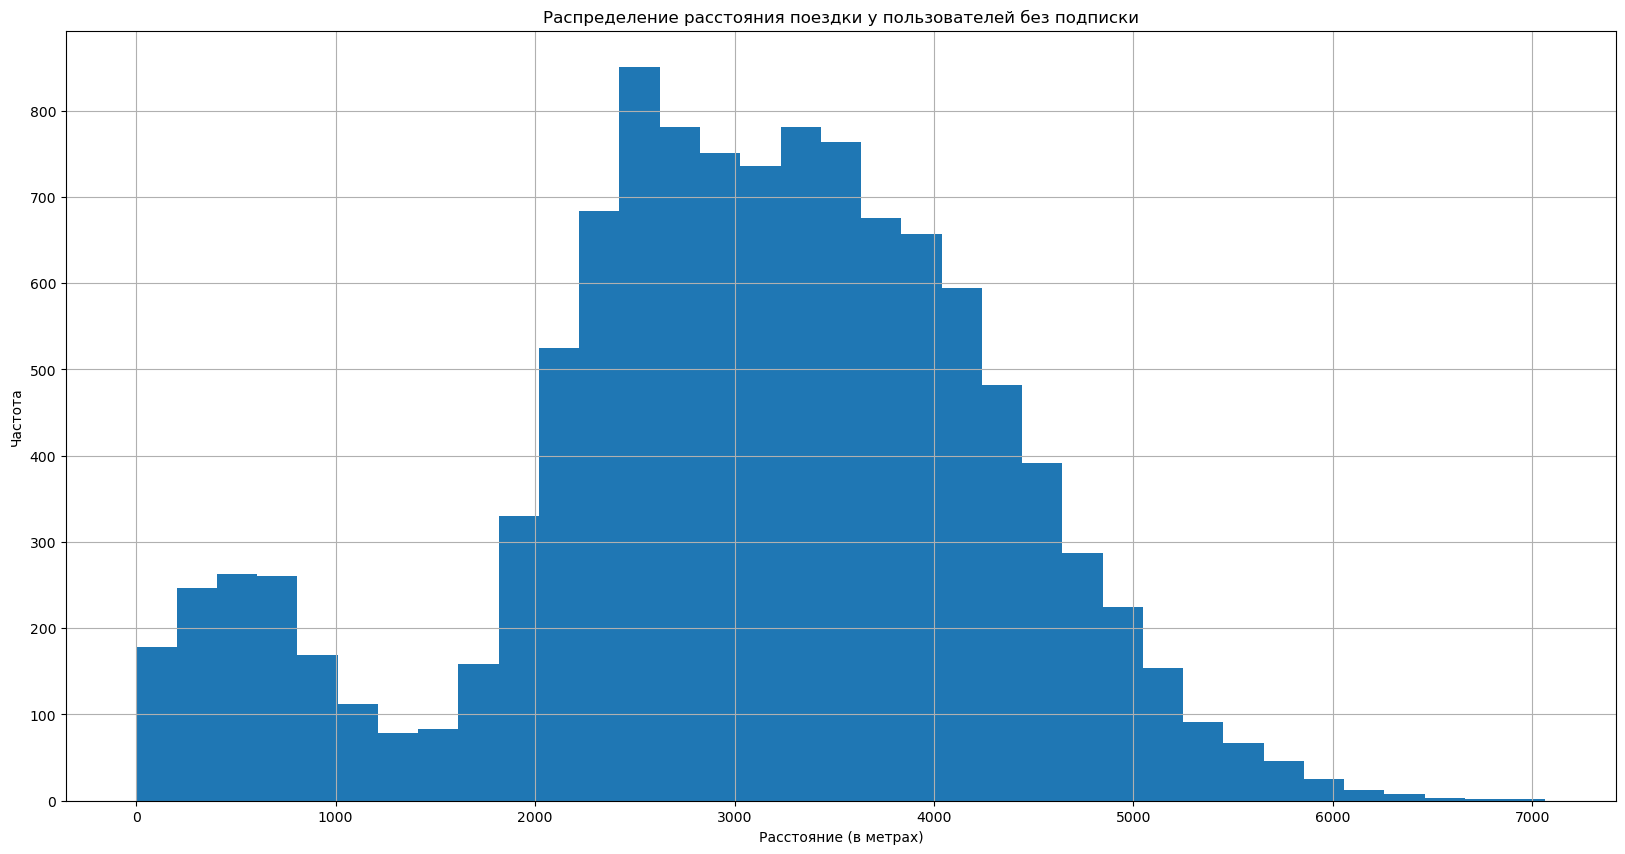

In [33]:
data_subscription_free.plot(kind='hist', y='distance', bins=(35), figsize=(20,10), grid=True, legend=False,
                            title="Распределение расстояния поездки у пользователей без подписки");
plt.xlabel('Расстояние (в метрах)');
plt.ylabel('Частота');



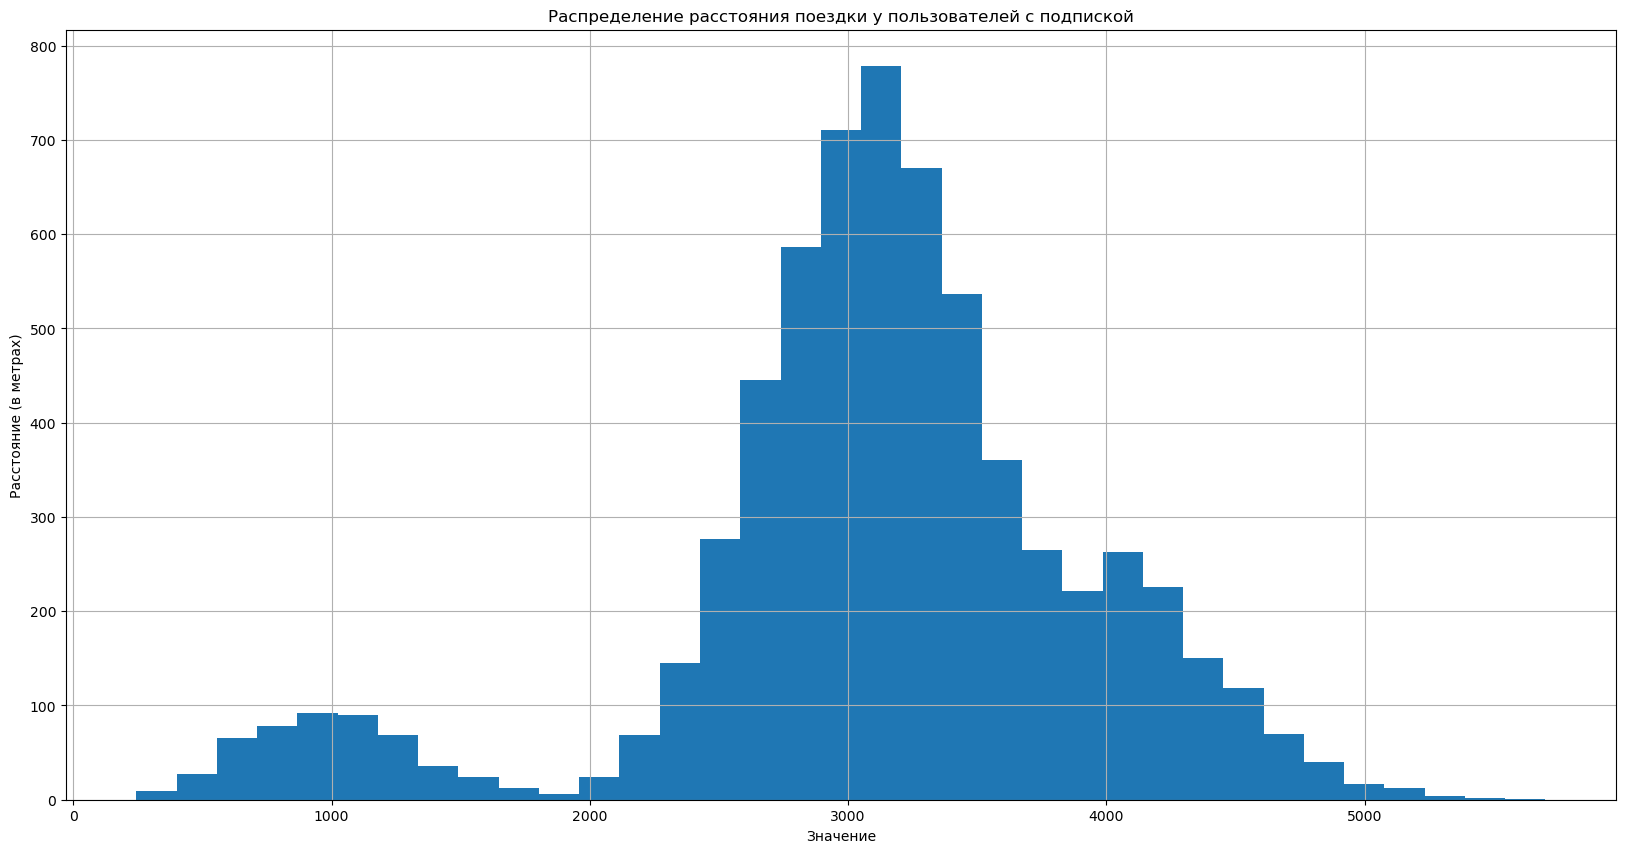

In [34]:
data_subscription_ultra.plot(kind='hist', y='distance', bins=(35), figsize=(20,10), grid=True, legend=False,
                             title="Распределение расстояния поездки у пользователей с подпиской");
plt.xlabel('Значение');
plt.ylabel('Расстояние (в метрах)');

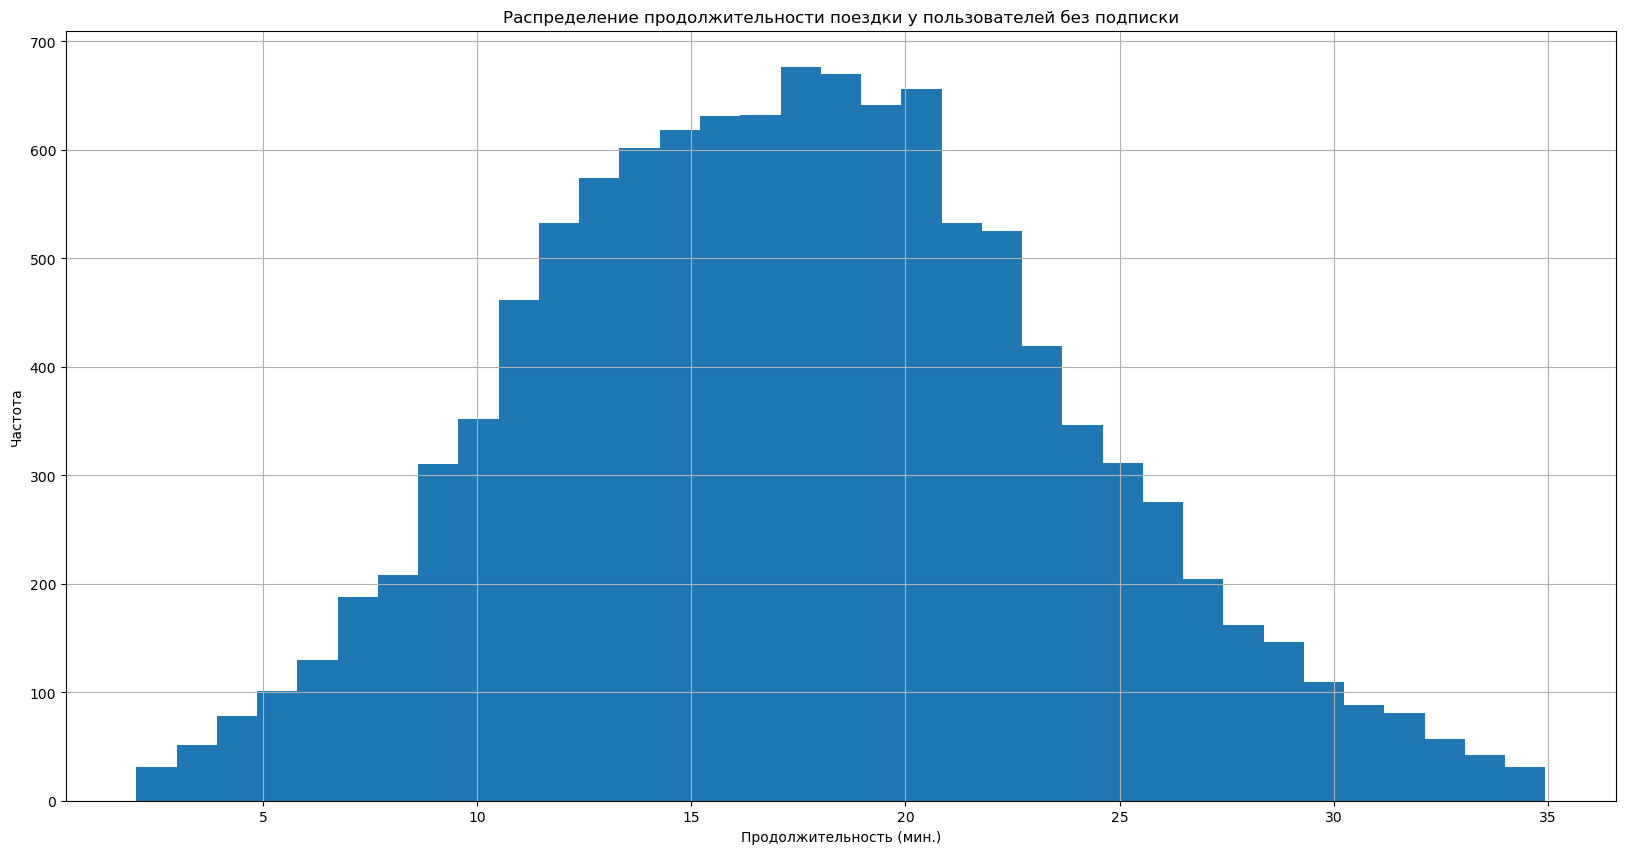

In [35]:
data_subscription_free.plot(kind='hist', y='duration', bins=(35), figsize=(20,10), grid=True, legend=False,
                            title="Распределение продолжительности поездки у пользователей без подписки");
plt.xlabel('Продолжительность (мин.)');
plt.ylabel('Частота');


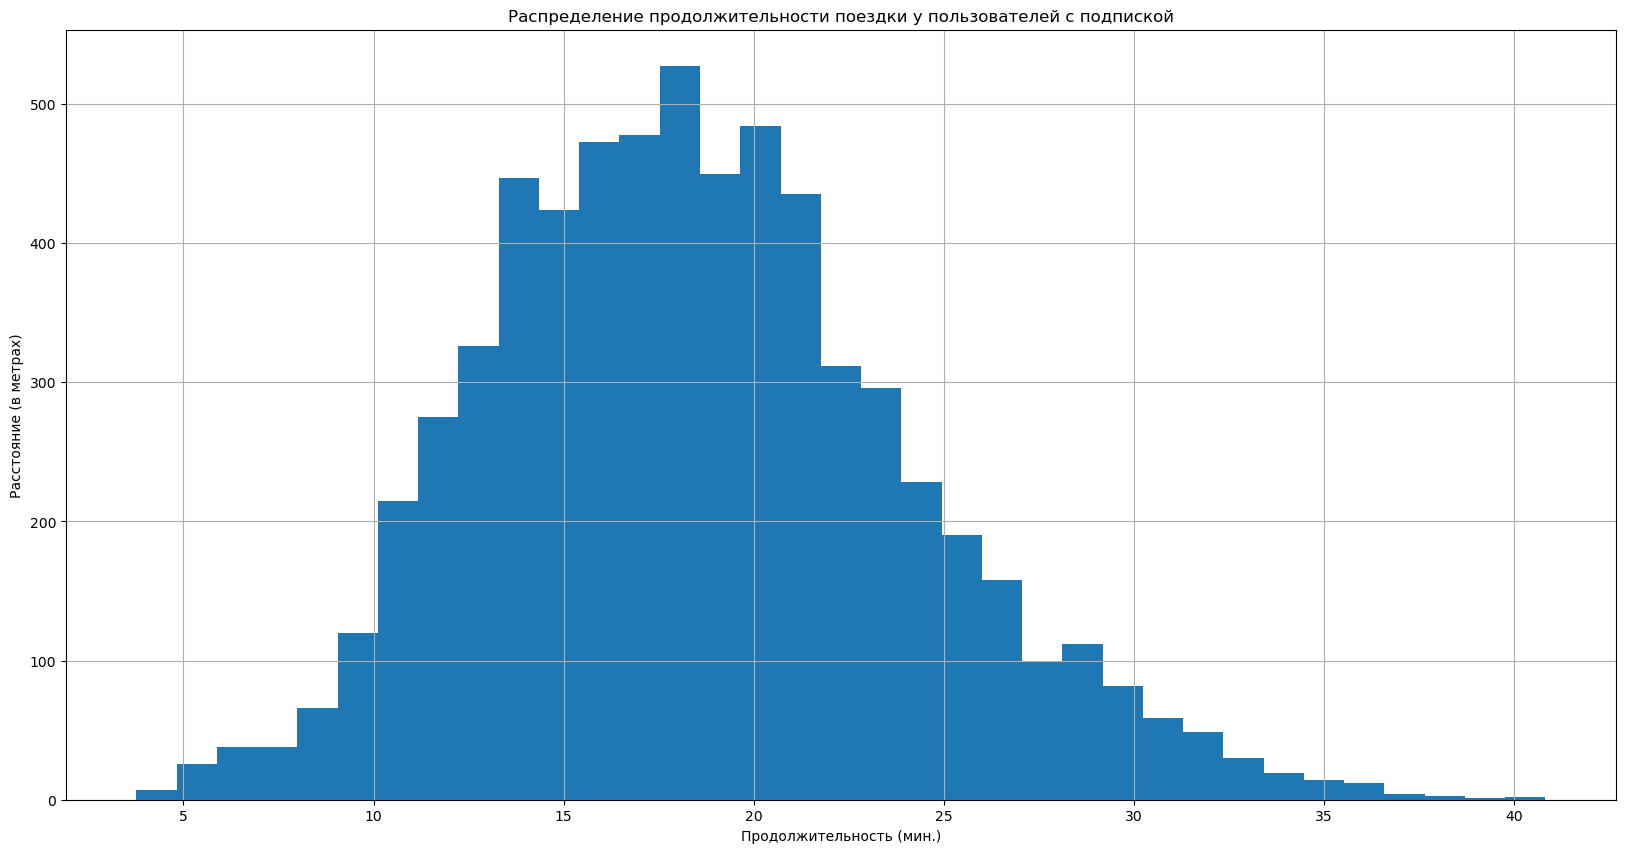

In [36]:
data_subscription_ultra.plot(kind='hist', y='duration', bins=(35), figsize=(20,10), grid=True, legend=False,
                             title="Распределение продолжительности поездки у пользователей с подпиской");
plt.xlabel('Продолжительность (мин.)');
plt.ylabel('Расстояние (в метрах)');

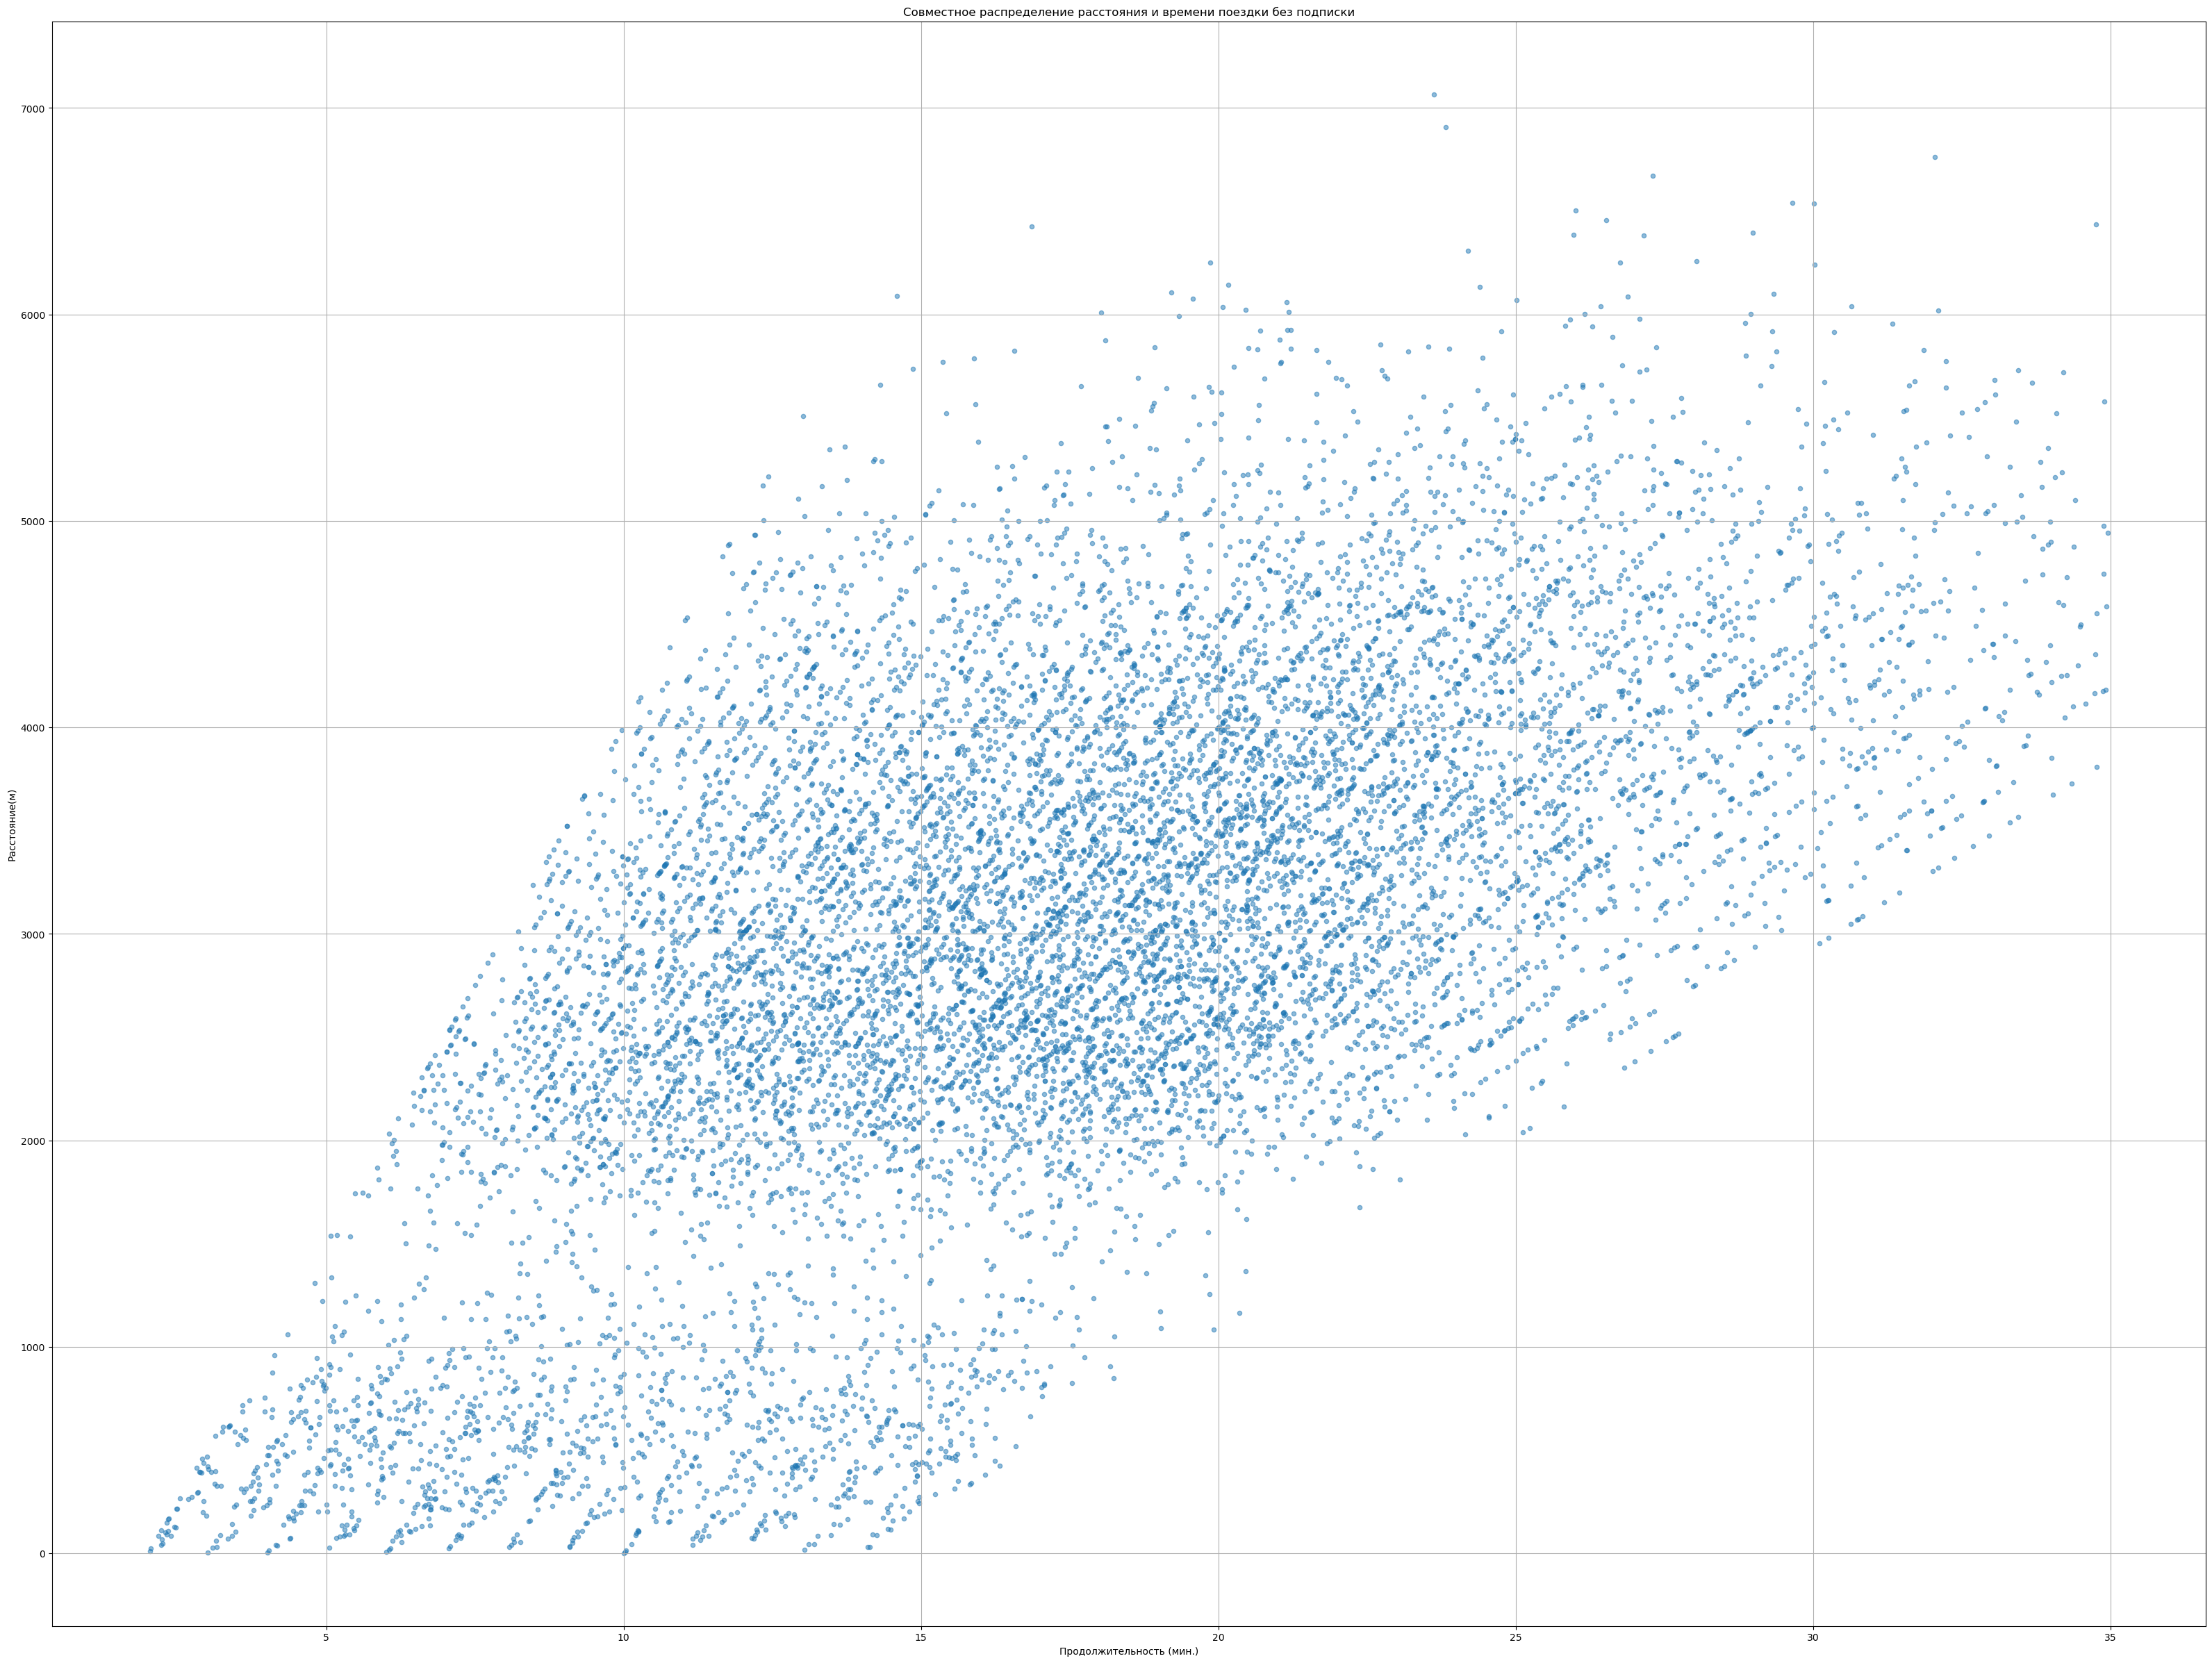

In [37]:
data_subscription_free.plot(x='duration', y = 'distance', kind ='scatter', figsize=(40,30),alpha = 0.5, grid = True,
               title = 'Совместное распределение расстояния и времени поездки без подписки');
plt.xlabel('Продолжительность (мин.)');
plt.ylabel('Расстояние(м)');

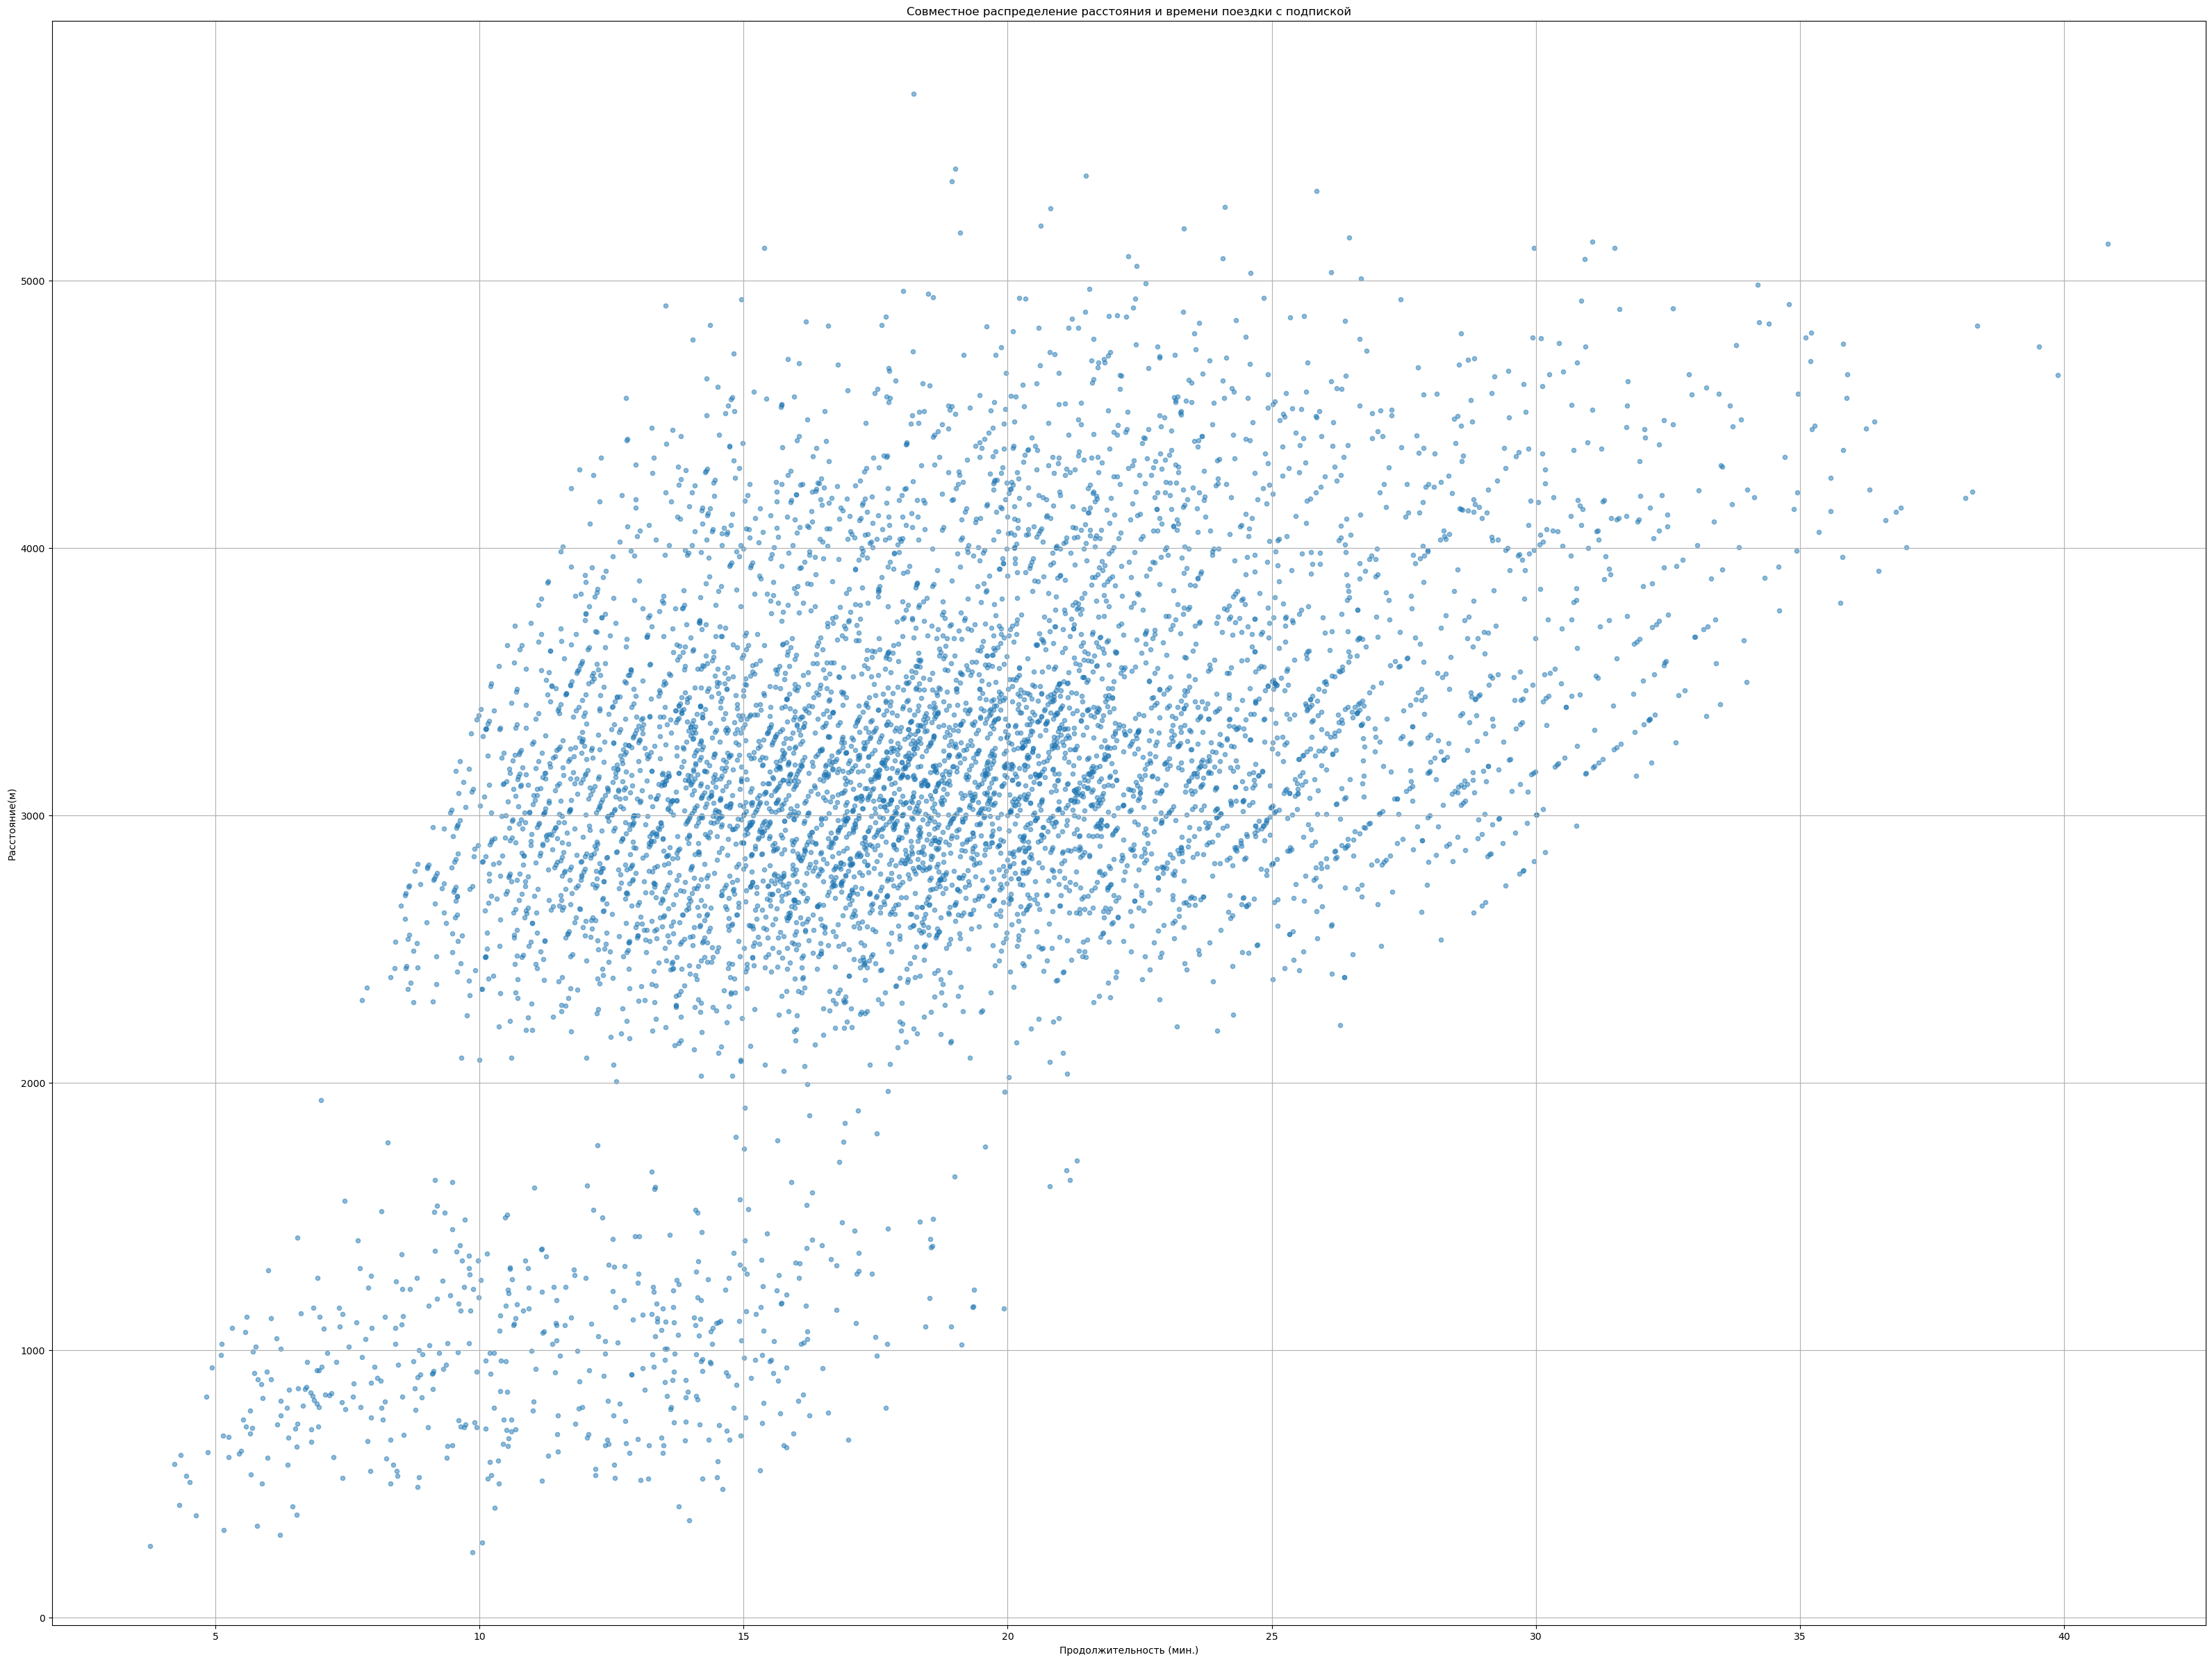

In [38]:
data_subscription_ultra.plot(x='duration', y = 'distance', kind ='scatter', figsize=(40,30),alpha = 0.5, grid = True,
               title = 'Совместное распределение расстояния и времени поездки с подпиской');
plt.xlabel('Продолжительность (мин.)');
plt.ylabel('Расстояние(м)');

Пользователи с подпиской в целом редко совершают поездки на короткие расстояния. Распределение продолжительности поездки практически не зависит от типа подписки.

#### Шаг 5. Подсчёт выручки

Созадим датафрейм с агрегированными данными о поездках на основе датафрейма с объединёнными данными; найдем суммарное расстояние, количество поездок и суммарное время для каждого пользователя за каждый месяц.

Также добавим столбец с помесячной выручкой, которую принес каждый пользователь и типом подписки (для удобства проверки гипотез).

In [39]:
data_merge['duration_ceill']=np.ceil(data_merge['duration']) 
data_merge['trip_price']=data_merge['duration_ceill']*data_merge['minute_price']+data_merge['start_ride_price']

data_merge_pivot= data_merge.pivot_table(
    index=['user_id', 'month'],
    values=['duration','distance','trip_price','subscription_fee'],
    aggfunc={'duration':"sum",'distance':['sum','count'], 'trip_price':'sum','subscription_fee':'min'})
data_merge_pivot.columns=['number_of_trips', 'total_distance','total_duration','subscription_fee', 'revenue']

data_merge_pivot['revenue'] = data_merge_pivot['revenue'] + data_merge_pivot['subscription_fee']

display(data_merge_pivot.head(15));

number_of_trips  total_distance  total_duration  \
user_id month                                                    
1       1                    2     7027.511294       41.416640   
        4                    1      754.159807        6.232113   
        8                    2     6723.470560       44.776802   
        10                   2     5809.911100       31.578017   
        11                   3     7003.499363       53.397424   
        12                   2     6751.629942       27.203912   
2       3                    3    10187.723006       60.959959   
        4                    2     6164.381824       39.048633   
        6                    1     3255.338202       13.851127   
        7                    2     6780.722964       46.170157   
        8                    1      923.007439        6.914760   
        10                   1     2824.636598       18.779128   
        12                   1     3828.248580       11.920514   
3       1                    1     3061.777147       12.654443   
        2                    2     5421.152016       37.568637   

               subscription_fee  revenue  
user_id month                             
1       1                   199    451.0  
        4                   199    241.0  
        8                   199    475.0  
        10                  199    391.0  
        11                  199    535.0  
        12                  199    367.0  
2       3                   199    577.0  
        4                   199    439.0  
        6                   199    283.0  
        7                   199    487.0  
        8                   199    241.0  
        10                  199    313.0  
        12                  199    271.0  
3       1                   199    277.0  
        2                   199    433.0

#### Шаг 6. Проверка гипотез

#####  Гипотеза о продолжительности поездок пользователей с подпиской

 Важно понять, тратят ли пользователи с подпиской больше времени на поездки? Если да, то пользователи с подпиской могут быть «выгоднее» для компании. 

In [40]:
print('Средняя с подпиской:', data_subscription_ultra['duration'].mean())
print('Средняя без подписки:', data_subscription_free['duration'].mean())
print('Дисперсия с подпиской:', data_subscription_ultra['duration'].var())
print('Дисперсия без подписки:', data_subscription_free['duration'].var())

Средняя с подпиской: 18.54198516280583
Средняя без подписки: 17.530771268800226
Дисперсия с подпиской: 31.047722583624328
Дисперсия без подписки: 37.977746318725


Нулевая гипотеза: средняя дистанция поездок пользователей с подпиской равна средняй дистанции поездок пользователей без подписки

Альтернатива: средняя дистанция поездок пользователей с подпиской больше средняй дистанции поездок пользователей без подписки

Дисперсии достаточно близки чтобы не выставлять параметр $equal\_var$ в $False$

In [41]:
alpha = 0.01 # уровень статистической значимости
# если p-value окажется меньше него, отвергнем гипотезу
print(data_subscription_ultra.shape[0])
print(data_subscription_free.shape[0])
# Ради интереса можем посмотреть какое p-value получается при меньших подвыборках
ultra_sample = data_subscription_ultra['duration']#.sample(1000)
free_sample = data_subscription_free['duration']#.sample(1000)

results = st.ttest_ind(ultra_sample,free_sample, alternative='greater')

print('p-значение:', results.pvalue)

if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу') 

6500
11473
p-значение: 4.704468074453899e-28
Отвергаем нулевую гипотезу


Подтвердили альтернативную гипотезу с очень высокой степенью уверенности. Пользователи с подпиской действительно ездят дальше.

##### Гипотеза о средней дистанции поездки


 Расстояние одной поездки в 3130 метров — оптимальное с точки зрения износа самоката. Можно ли сказать, что среднее расстояние, которое проезжают пользователи с подпиской за одну поездку, не превышает 3130 метров?
 

In [42]:
print(data_subscription_ultra['distance'].mean())

3115.4453880370247


Нулевая гипотеза: средняя дистанция поездок пользовотелей с подпиской равна оптимальному расстоянию;

Альтернатива: средняя дистанция поездок пользовотелей с подпиской меньше оптимального расстояния;

In [43]:
optimal_distance = 3130

alpha = 0.05 # укажите уровень статистической значимости

sample = data_subscription_ultra['distance']#.sample(2000);
results =st.ttest_1samp(sample, optimal_distance, alternative='less') 

print('p-значение:', results.pvalue ) # добавьте в аргумент p-value

if (results.pvalue < alpha):# сравните полученный p-value и уровень значимости):
    print('Отвергаем нулевую гипотезу: пользователи с подпиской проезжают меньше, нежели оптимальное расстояние')
else:
    print('Не получилось отвергнуть нулевую гипотезу: возможно что пользователи с подпиской'
          ' проезжают больше оптимального расстояния')

p-значение: 0.08046311521502146
Не получилось отвергнуть нулевую гипотезу: возможно что пользователи с подпиской проезжают больше оптимального расстояния


In [44]:
optimal_distance = 3130

alpha = 0.05 # укажите уровень статистической значимости

sample = data_subscription_ultra['distance']#.sample(2000);
results = st.ttest_1samp(sample, optimal_distance, alternative='greater') 

# у нас поменялись местами нулевая и альтернативная гипотезы, поэтому инвертируем p-value
pvalue = 1 - results.pvalue

print('p-значение:', pvalue ) # добавьте в аргумент p-value

if (pvalue < alpha):# сравните полученный p-value и уровень значимости):
    print('Отвергаем нулевую гипотезу: пользователи с подпиской проезжают меньше, нежели оптимальное расстояние')
else:
    print('Не получилось отвергнуть нулевую гипотезу: возможно что пользователи с подпиской'
          ' проезжают больше оптимального расстояния')

p-значение: 0.08046311521502147
Не получилось отвергнуть нулевую гипотезу: возможно что пользователи с подпиской проезжают больше оптимального расстояния


Вывод: Скорее всего в среднем пользователи с подпиской в среднем проезжают расстояние меньше оптимального, но мы не можем утверждать это с достаточной степенью уверенности.


##### Гипотеза о размере помесячной выурчки


Проверим гипотезу о том, будет ли помесячная выручка от пользователей с подпиской по месяцам выше, чем выручка от пользователей без подписки. 

In [45]:
ultra_pivot=data_merge_pivot.query('subscription_fee !=0')
free_pivot=data_merge_pivot.query('subscription_fee ==0')
print('Средняя с подпиской:', ultra_pivot['revenue'].mean())
print('Средняя без подписки:', free_pivot['revenue'].mean())
print('Дисперсия с подпиской:', ultra_pivot['revenue'].var())
print('Дисперсия без подписки:', free_pivot['revenue'].var())

Средняя с подпиской: 362.7921906022502
Средняя без подписки: 329.3326437121324
Дисперсия с подпиской: 7790.310733351123
Дисперсия без подписки: 33587.313363730915


Нулевая гипотеза: средняя помесячная выручка пользователей с подпиской равна средней помесячной выручке пользователей без подписки;

Альтернатива: средняя помесячная выручка пользователей с подпиской больше средней помесячной выручке пользователей без подписки

Дисперсии отличаются значительно, поэтому нужно выставлять параметр `equal_var` в `False`

In [46]:
alpha = 0.01 # уровень статистической значимости
# если p-value окажется меньше него, отвергнем гипотезу
print(ultra_pivot.shape[0])
print(free_pivot.shape[0])
# Ради интереса можем посмотреть какое p-value получается при меньших подвыборках
ultra_pivot_sample = ultra_pivot['revenue']#.sample(100)
free_pivot_sample = free_pivot['revenue']#.sample(100)

results = st.ttest_ind(ultra_pivot_sample,free_pivot_sample, alternative='greater', equal_var=False)

print('p-значение:', results.pvalue)

if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу') 

4533
6767
p-значение: 2.4970242872858465e-38
Отвергаем нулевую гипотезу


Вывод: Подтвердили альтернативную гипотезу с очень высокой степенью уверенности. Пользователи с подпиской действительно тратят больше.

##### Теоретический вопрос

 Представьте такую ситуацию: техническая команда сервиса обновила сервера, с которыми взаимодействует мобильное приложение. Она надеется, что из-за этого количество обращений в техподдержку значимо снизилось. Некоторый файл содержит для каждого пользователя данные о количестве обращений до обновления и после него. Какой тест вам понадобился бы для проверки этой гипотезы?



Ответ: Для проверки этой гипотезы потребовался бы тест для проверки левостороней гипотезы о равенстве среднего значения генеральной совокупности до и после изменения(тест для двух зависимых выборок).

Нулевая гипотеза: среднее число обращений в техподдержку до обновления равно среднему числу обращений после обновления сервера.

Альтернатива: среднее число обращений после обновления сервера меньше чем среднее число обращений до обновления. 

Метод в python: `scipy.stats.ttest_rel`; 
аргументы - выборка до изменения, выборка после изменения;
аргумент `alternative`: `alternative="less"`

#### Итог

##### Предобработка данных

Описание предобработки данных :
* в датасете “data_rides” данные в столбце “date” привели к формату даты библиотеки “pandas”;
* в датасет “data_rides” добавлен столбец “month” с месяцем поездки;
*  удалены явные дубликаты из датасета "data_users";
* все датасеты проверены на пропущенные значения и дубликаты; 
* были обнаружены аномально быстрые поездки, удалили их из  data_rides”


##### Вывод

По количеству пользователей города в выборке представлены довольно равномерно , по 11-14% на город от общего объема выборки (то есть выборка стратифицирована по городам). 

Доля пользователей с подпиской составляет 46% от общего числа пользователей.

Средний возраст пользователя сервиса – 25 лет; 5% пользователей – подростки.

Средняя продолжительность поездки пользователей без подписки  17.5 минут,  дистанция 3 км.

Средняя продолжительность поездки пользователей с подпиской  18.5 минут,  дистанция 3.1 км.

Пользователи с подпиской в целом редко совершают поездки на короткие расстояния. Распределение продолжительности поездки практически не зависит от типа подписки.

Были рассмотрены следующие гипотезы:
1. пользователи с подпиской совершают более долгие поездки, чем пользователи без подписки;
1. пользователи с подпиской в среднем совершают поездки на расстояние не превышающее оптимальное с точки зрения износа самокатов; 
1.  пользователи с подпиской приносят большую месячную выручку чем без подписки;

Первая и третья гипотезы были приняты с очень высокой степенью достоверности($p-value <10^{-20}$). 

Достоверность второй гипотезы недостаточна для ее однозначного принятия ($p-value =0.08$).
